In [44]:
# regression-multiple-methods.ipynb
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

Metrics - Train Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.83  1.41           0.06        51.47        0.00
SVM Regression          0.55  2.33           0.02        68.88        0.00
RandomForest            1.00  0.11           2.93         3.77        0.15
XGBoost                 1.00  0.18           2.37         1.05        0.59
knn                     1.00  0.22           2.51         0.71        0.70
Neural Network-10       0.94  0.85           0.16        22.92        0.00
-------------------------------------------------
Metrics - Test Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.82  1.50           0.08        12.50        0.00
SVM Regression          0.56  2.33           0.03        23.41        0.00
RandomForest            0.99  0.32           1.83         0.90        0.64
XGBoost                 0.99  0.30           1.85         1.00        0.61
knn  

(                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
 Linear Regression       0.83  1.41           0.06        51.47        0.00
 SVM Regression          0.55  2.33           0.02        68.88        0.00
 RandomForest            1.00  0.11           2.93         3.77        0.15
 XGBoost                 1.00  0.18           2.37         1.05        0.59
 knn                     1.00  0.22           2.51         0.71        0.70
 Neural Network-10       0.94  0.85           0.16        22.92        0.00,
                    R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
 Linear Regression       0.82  1.50           0.08        12.50        0.00
 SVM Regression          0.56  2.33           0.03        23.41        0.00
 RandomForest            0.99  0.32           1.83         0.90        0.64
 XGBoost                 0.99  0.30           1.85         1.00        0.61
 knn                     0.99  0.29           1.97         0.97        0.62
 Neural Net

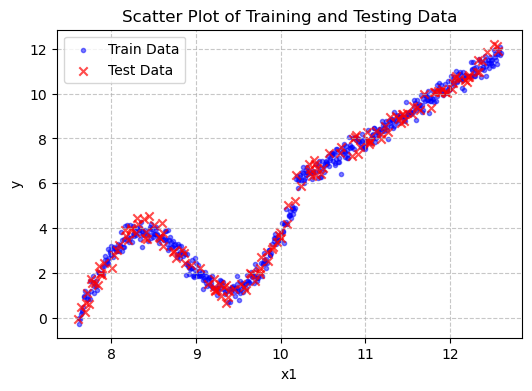

<Figure size 2000x2400 with 0 Axes>

In [59]:
# To ensure reproducibility

def run_ml_models(polynomial_dof=1, draw_plots=True, enable_standardization=True, print_metrics=True,
                  enable_outliers=False, analyze_neural_net_algos=False):
    np.random.seed(42)

    # Read data from Excel file
    file_path = 'regression-multiple-methods.xlsx'
    train_data = pd.read_excel(file_path, sheet_name='train')
    test_data = pd.read_excel(file_path, sheet_name='test')
    # Scatter Plot with 'x1' and 'y' columns ---

    # Select the specified columns
    x_train = train_data['x1']
    y_train = train_data['y']
    x_test = test_data['x1']
    y_test = test_data['y']

    # Create the scatter plot
    plt.figure(figsize=(6, 4))

    # Scatter plot for training data (blue circles)
    plt.scatter(x_train, y_train, color='blue', label='Train Data', alpha=0.5, marker='.')

    # Scatter plot for test data (red crosses)
    plt.scatter(x_test, y_test, color='red', label='Test Data', alpha=0.7, marker='x')

    # Add titles, labels, and legend
    plt.title('Scatter Plot of Training and Testing Data')
    plt.xlabel('x1')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    # Separate features and target variable in train data
    X_train = train_data.drop(columns=['y'])
    y_train = train_data['y']

    # Separate features and target variable in test data
    X_test = test_data.drop(columns=['y'])
    y_test = test_data['y']
    # # Adding outliers (UNCOMMENT ONLY WHEN REQUIRED! SEE THE PROBLEM STATEMENTs ...)
    if enable_outliers:
        X_train = np.array(list(X_train['x1']) + [X_train['x1'].mean() + x for x in np.random.randn(5)]).reshape(-1, 1)
        y_train = np.array(list(y_train) + [y_train.max() + 4 + x for x in np.random.randn(5)])
    # Use PolynomialFeatures to create new features features
    poly = PolynomialFeatures(degree=polynomial_dof)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    # standardization of the data0
    if enable_standardization:
        scaler = StandardScaler()
        X_train_poly = scaler.fit_transform(X_train_poly)
        X_test_poly = scaler.transform(X_test_poly)
    ####################################
    # Save the augmented data set to a file for review

    # Create dataframe with test data and additional features
    # Get feature names
    feature_names = poly.get_feature_names_out()
    augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
    augmented_data['y'] = train_data['y']

    # # Write dataframe to CSV
    augmented_data.to_csv('augmented_train_data.csv', index=False)
    ####################################
    ####################################
    # Save the augmented data set to a file for review

    # Create dataframe with test data and additional features
    # Get feature names
    feature_names = poly.get_feature_names_out()
    augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
    augmented_data['y'] = test_data['y']

    # # Write dataframe to CSV
    augmented_data.to_csv('augmented_test_data.csv', index=False)
    ####################################
    # Algorithms
    algorithms = {
        'Linear Regression': LinearRegression(),
        'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
        'RandomForest': RandomForestRegressor(),
        'XGBoost': GradientBoostingRegressor(),
        'knn': KNeighborsRegressor(),
        'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
    }

    algorithms_neural_network = {
        'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
        'Neural Network-10-10': MLPRegressor(hidden_layer_sizes=[10, 10], max_iter=20000),
        'Neural Network-10-10-10': MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=20000),
        'Neural Network-10-10-10-10-10': MLPRegressor(hidden_layer_sizes=[10, 10, 10,10,10], max_iter=20000)
    }

    if analyze_neural_net_algos:
        algorithms = algorithms_neural_network

    # Metric tables
    metric_table_train = pd.DataFrame()
    metric_table_test = pd.DataFrame()

    # Create a grid of subplots
    # if draw_plots:
    fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
    fig_row = -1

    # Run the algorithms ... create metrics and plots
    for algorithm_name, algorithm in algorithms.items():
        # Train model
        algorithm.fit(X_train_poly, y_train)

        # Train predictions
        y_train_pred = algorithm.predict(X_train_poly)

        # Test predictions
        y_test_pred = algorithm.predict(X_test_poly)

        # Train metrics
        r2_train = algorithm.score(X_train_poly, y_train)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

        # Test metrics
        r2_test = algorithm.score(X_test_poly, y_test)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

        # Additional metrics using statsmodels for all algorithms
        residuals_train = y_train - y_train_pred
        residuals_test = y_test - y_test_pred

        durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
        jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

        durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
        jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

        # Update metric tables
        metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
        metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
        metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
        metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
        metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

        metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
        metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
        metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
        metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
        metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

        # Create the plots
        # if draw_plots:
        fig_row = fig_row + 1

        axs[fig_row, 0].scatter(X_train, y_train)
        axs[fig_row, 0].scatter(X_train, y_train_pred)
        axs[fig_row, 0].set_title(algorithm_name + " - Train")

        axs[fig_row, 1].scatter(X_train, residuals_train)
        axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

        axs[fig_row, 2].scatter(X_test, y_test)
        axs[fig_row, 2].scatter(X_test, y_test_pred)
        axs[fig_row, 2].set_title(algorithm_name + " - Test")

        axs[fig_row, 3].scatter(X_test, residuals_test)
        axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")

        ############################
    if draw_plots:
        plt.tight_layout()
        plt.show()
    else:
        plt.clf()

    if print_metrics:
        # Display the metrics' Tables
        print("Metrics - Train Data:\n")
        print(metric_table_train.to_string())
        print("-------------------------------------------------")

        print("Metrics - Test Data:\n")
        print(metric_table_test.to_string())
    return metric_table_train, metric_table_test


run_ml_models(polynomial_dof=1, draw_plots=False, enable_standardization=True)

****1.  Review the Jupyter Notebook multiple-regression-methods.ipynb, along with the  data file multiple-regression-methods.xlsx:****

  **a) Execute the code. Analyze the resulting plots and metrics.**


  **b) Choose the best algorithm for the given dataset. Justify your choice.**
    ### 🌳 Performance Comparison: Random Forest vs XGBoost

| **Metric** | **Random Forest (Train)** | **Random Forest (Test)** | **XGBoost (Train)** | **XGBoost (Test)** |
|-------------|----------------------------|---------------------------|----------------------|---------------------|
| **R²** | 0.9990 | 0.9714 | 0.9971 | 0.9928 |
| **RMSE** | 0.1092 | 0.3199 | 0.1845 | 0.2979 |
| **Durbin–Watson** | 2.316 | 1.835 | 2.372 | 1.851 |
| **Jarque–Bera p-value** | 0.151 | 0.636 | 0.592 | 0.605 |

**Interpretation:**
- Both models fit the data very well with high R² and low RMSE.
- Random Forest shows slightly higher R² on the training set, suggesting a tighter fit.
- XGBoost performs marginally better on the test set, indicating better generalization.
- Durbin–Watson values near 2 show residuals are uncorrelated for both models.
- Jarque–Bera p-values > 0.05 confirm that residuals are approximately normal.


 **c) What is your take-away from the way the code has been structured to generate the results?**

***Review sklearn documentation for each sklearn function used in the Notebook (eg. PolyNomialFeatures, LinearRegression, mean_squared_error, etc.) and create a summary of each to explain the functionality, the input parameters, and the outputs. Present this in the form of a two-column Table (Function name | Description).***

### 📘 Summary of Functions from scikit-learn and statsmodels

| **Function / Class Name** | **Description (Functionality, Parameters, Outputs)** |
|-----------------------------|------------------------------------------------------|
| **PolynomialFeatures (sklearn.preprocessing)** | Generates polynomial and interaction features from input data. <br>**Parameters:** `degree` (max power), `include_bias` (add constant term), `interaction_only` (exclude powers). <br>**Output:** Transformed feature matrix with polynomial terms for non-linear regression. |
| **LinearRegression (sklearn.linear_model)** | Fits a linear model using Ordinary Least Squares (OLS). <br>**Parameters:** `fit_intercept`, `copy_X`, `n_jobs`. <br>**Output:** Fitted model with `.coef_`, `.intercept_`, and `.predict(X)`. |
| **train_test_split (sklearn.model_selection)** | Splits data into training and testing subsets. <br>**Parameters:** `test_size`, `train_size`, `random_state`, `shuffle`. <br>**Output:** `X_train, X_test, y_train, y_test`. |
| **StandardScaler (sklearn.preprocessing)** | Standardizes data by removing the mean and scaling to unit variance. <br>**Parameters:** `with_mean`, `with_std`. <br>**Output:** Scaled version of input data. |
| **MinMaxScaler (sklearn.preprocessing)** | Scales features to a given range, usually [0, 1]. <br>**Parameters:** `feature_range`. <br>**Output:** Normalized dataset preserving shape but adjusted scale. |
| **mean_squared_error (sklearn.metrics)** | Computes mean squared error (MSE) or root MSE between predicted and actual values. <br>**Parameters:** `y_true`, `y_pred`, `squared=True` (set False for RMSE). <br>**Output:** Single numeric MSE or RMSE value. |
| **r2_score (sklearn.metrics)** | Returns the coefficient of determination (R²), indicating goodness of fit. <br>**Parameters:** `y_true`, `y_pred`. <br>**Output:** Value between -∞ and 1, where 1 means perfect fit. |
| **SVR (sklearn.svm)** | Support Vector Regression — fits data using support vectors with chosen kernel. <br>**Parameters:** `kernel` (‘linear’, ‘rbf’, etc.), `C` (regularization), `epsilon`. <br>**Output:** Model object for regression; `.predict(X)` gives target predictions. |
| **RandomForestRegressor (sklearn.ensemble)** | Builds an ensemble of decision trees using bootstrap aggregation (bagging). <br>**Parameters:** `n_estimators`, `max_depth`, `min_samples_split`, `random_state`. <br>**Output:** Fitted ensemble model with stable, low-variance predictions. |
| **KNeighborsRegressor (sklearn.neighbors)** | Predicts value based on average of *k* nearest neighbors. <br>**Parameters:** `n_neighbors`, `weights`, `metric`. <br>**Output:** Fitted model; `.predict(X)` gives averaged neighbor predictions. |
| **MLPRegressor (sklearn.neural_network)** | Multi-layer perceptron model for regression using backpropagation. <br>**Parameters:** `hidden_layer_sizes`, `activation`, `solver`, `max_iter`, `learning_rate`. <br>**Output:** Fitted neural network capable of modeling non-linear relationships. |
| **GridSearchCV (sklearn.model_selection)** | Performs exhaustive search over specified parameter grid with cross-validation. <br>**Parameters:** `estimator`, `param_grid`, `cv`, `scoring`. <br>**Output:** Best model (`best_estimator_`), best score, and CV results. |
| **cross_val_score (sklearn.model_selection)** | Evaluates estimator performance via cross-validation. <br>**Parameters:** `estimator`, `X`, `y`, `cv`, `scoring`. <br>**Output:** Array of validation scores. |
| **Pipeline (sklearn.pipeline)** | Chains preprocessing and model steps for cleaner workflow. <br>**Parameters:** list of tuples, e.g. `[('scaler', StandardScaler()), ('model', LinearRegression())]`. <br>**Output:** Unified object for `.fit()` and `.predict()` operations. |
| **add_constant (statsmodels.api)** | Adds an intercept column (constant term) to dataset for regression models. <br>**Parameters:** `data`, `has_constant`. <br>**Output:** DataFrame with a new constant column added. |
| **OLS (statsmodels.api)** | Fits an Ordinary Least Squares regression model. <br>**Parameters:** `endog` (dependent variable), `exog` (independent variables, often with constant added). <br>**Output:** `RegressionResults` object with `.summary()`, `.params`, `.resid`, etc. |
| **GLM (statsmodels.api)** | Generalized Linear Model for non-normal target distributions. <br>**Parameters:** `family` (e.g. Gaussian, Poisson), `link` function. <br>**Output:** Model fit summary and coefficients. |
| **Logit (statsmodels.api)** | Logistic regression model for binary outcomes. <br>**Parameters:** `endog`, `exog`. <br>**Output:** Fitted logistic regression model with `.summary()`. |
| **summary() (statsmodels RegressionResults)** | Displays detailed regression output including coefficients, p-values, R², F-statistic, etc. <br>**Parameters:** None (method of fitted model). <br>**Output:** Text/table summary of model results. |
| **fit() (statsmodels Model)** | Fits the specified model to the data. <br>**Parameters:** `method` (fitting algorithm, usually ‘normal’), `cov_type`. <br>**Output:** Fitted model results object. |
| **predict() (statsmodels RegressionResults)** | Generates predictions based on fitted model. <br>**Parameters:** `exog` (input data). <br>**Output:** Predicted dependent variable values. |


-----------------Running with polynomial degree=1---------------------


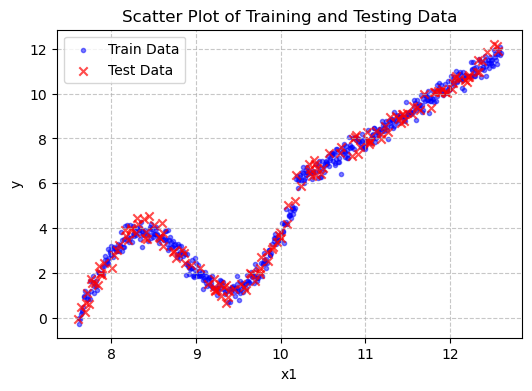

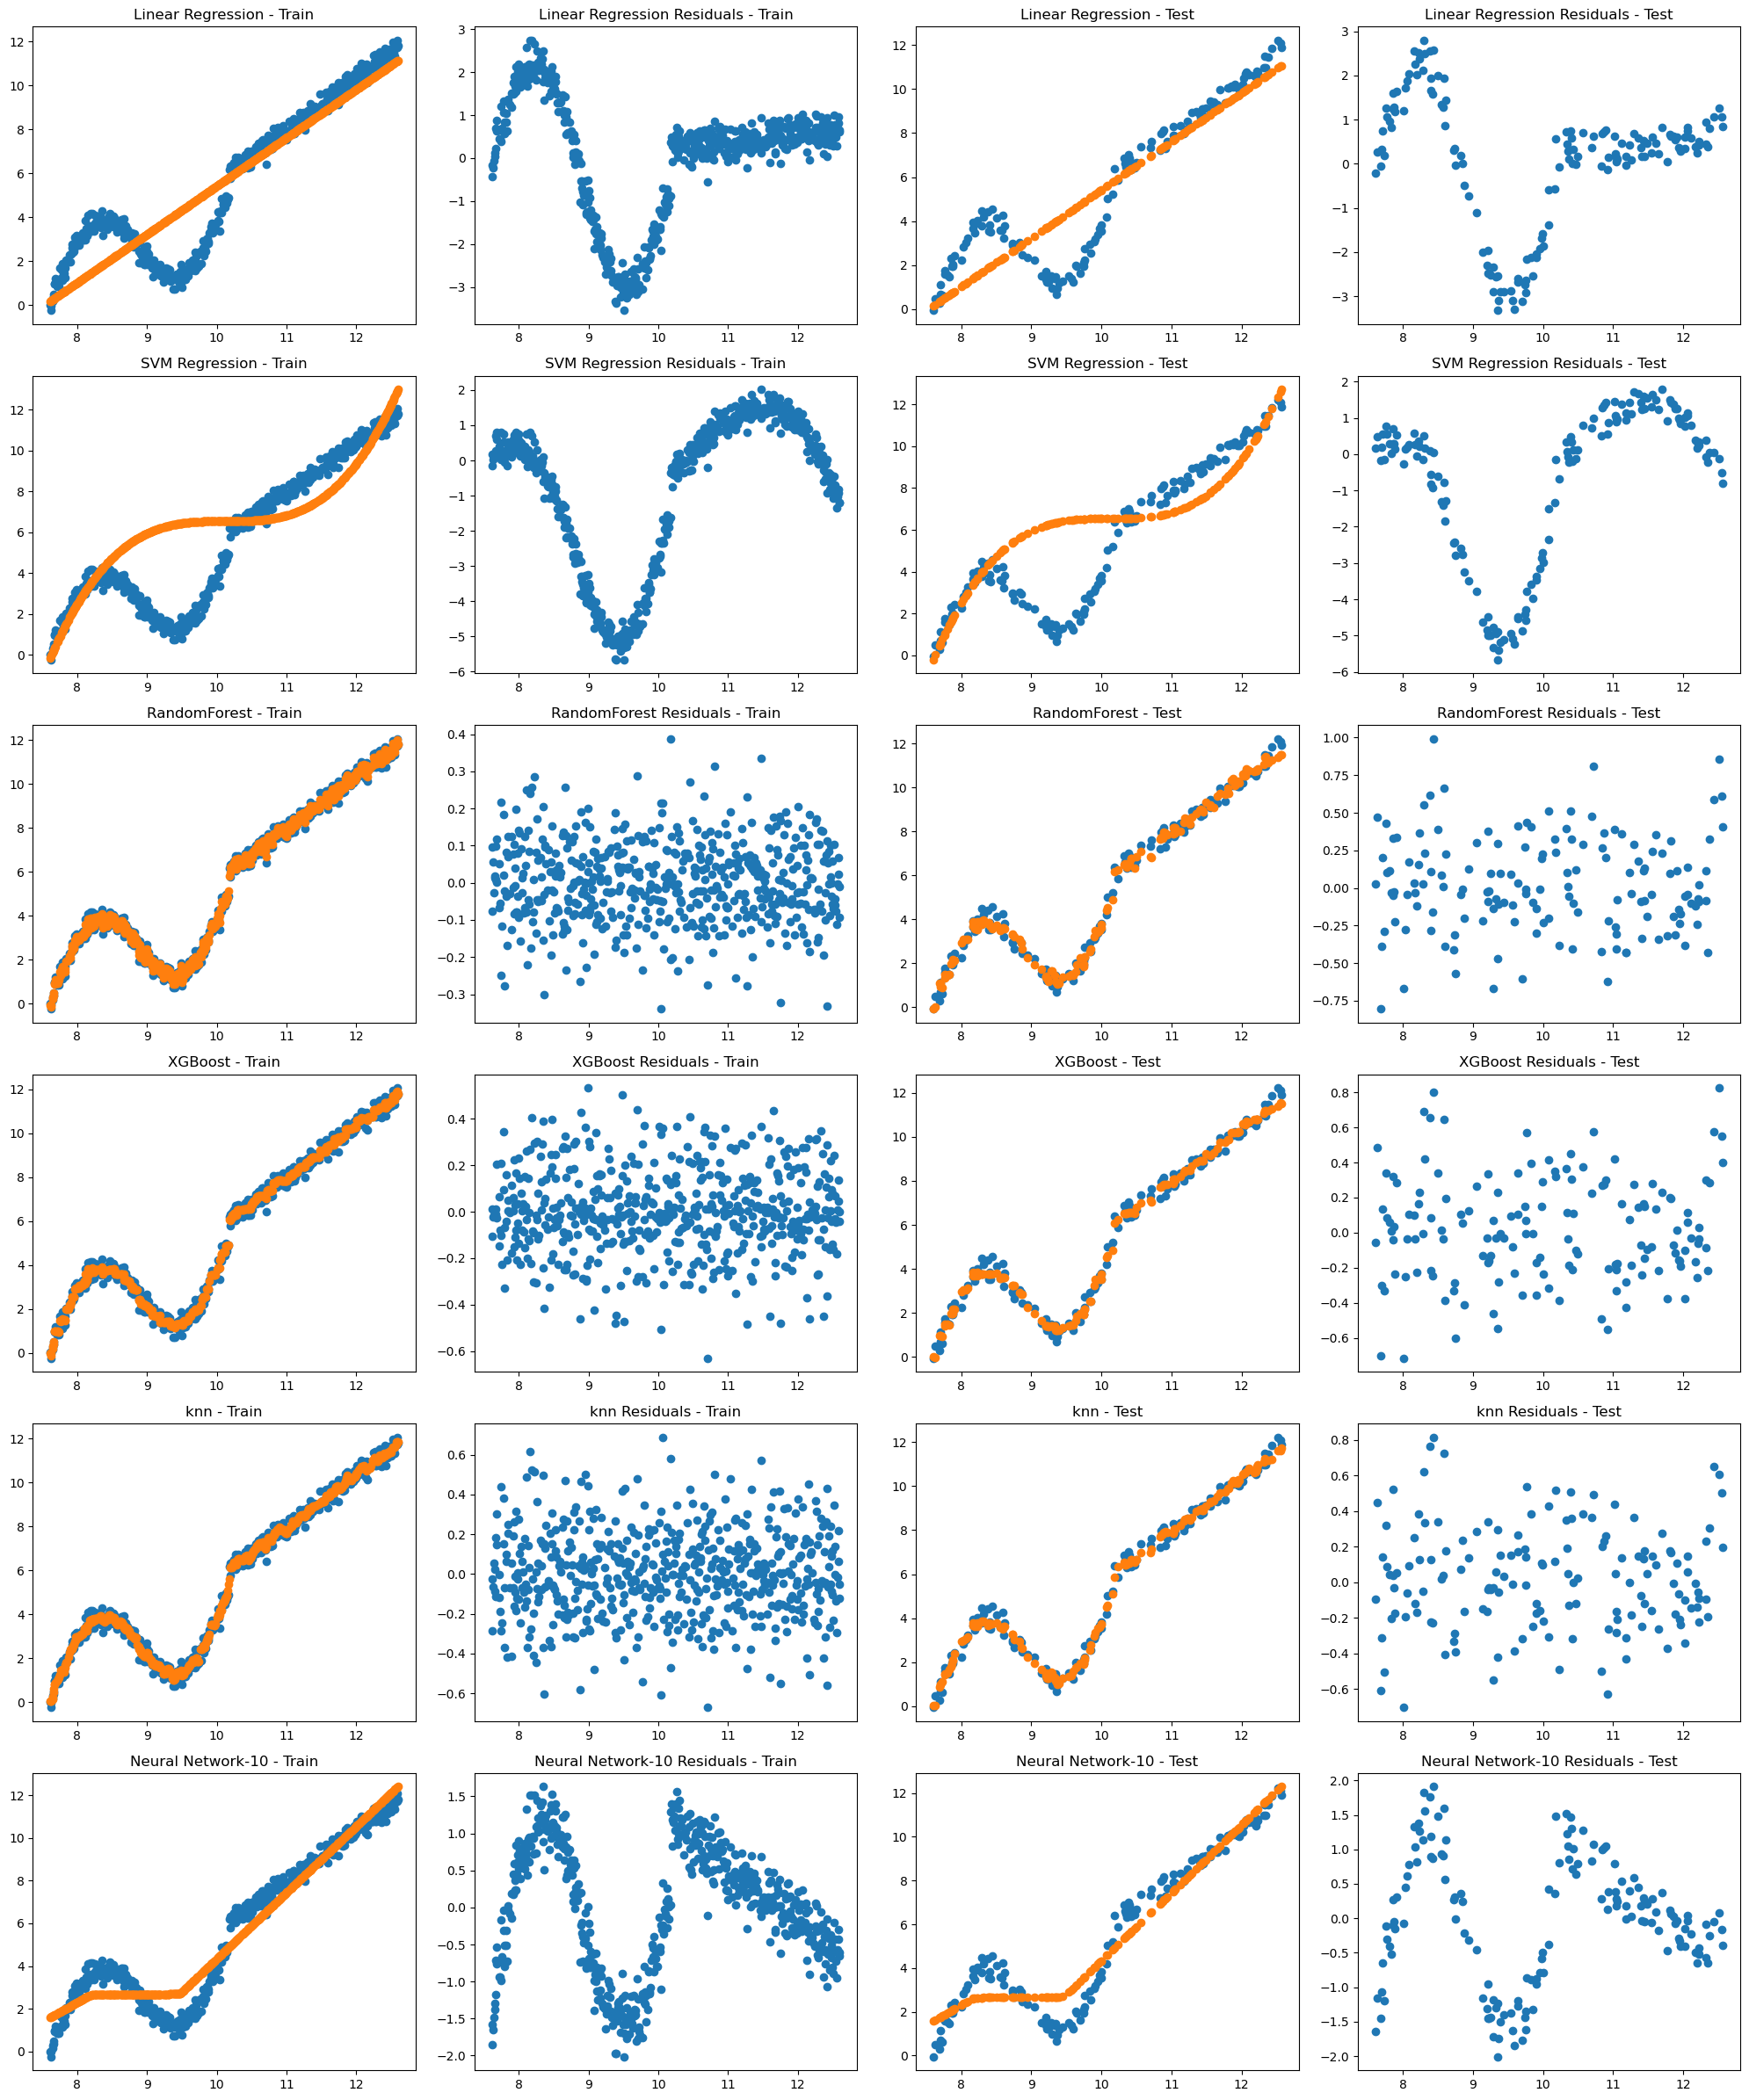

Metrics - Train Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.83  1.41           0.06        51.47        0.00
SVM Regression          0.55  2.33           0.02        68.88        0.00
RandomForest            1.00  0.11           2.93         3.77        0.15
XGBoost                 1.00  0.18           2.37         1.05        0.59
knn                     1.00  0.22           2.51         0.71        0.70
Neural Network-10       0.94  0.85           0.16        22.92        0.00
-------------------------------------------------
Metrics - Test Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.82  1.50           0.08        12.50        0.00
SVM Regression          0.56  2.33           0.03        23.41        0.00
RandomForest            0.99  0.32           1.83         0.90        0.64
XGBoost                 0.99  0.30           1.85         1.00        0.61
knn  

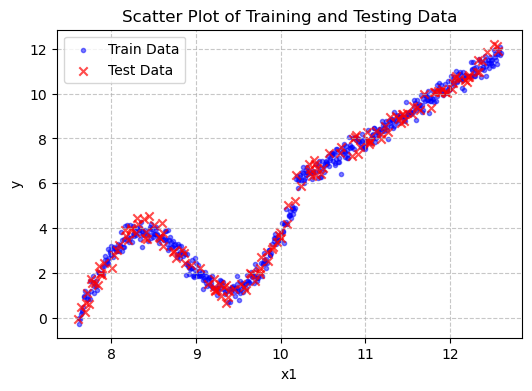

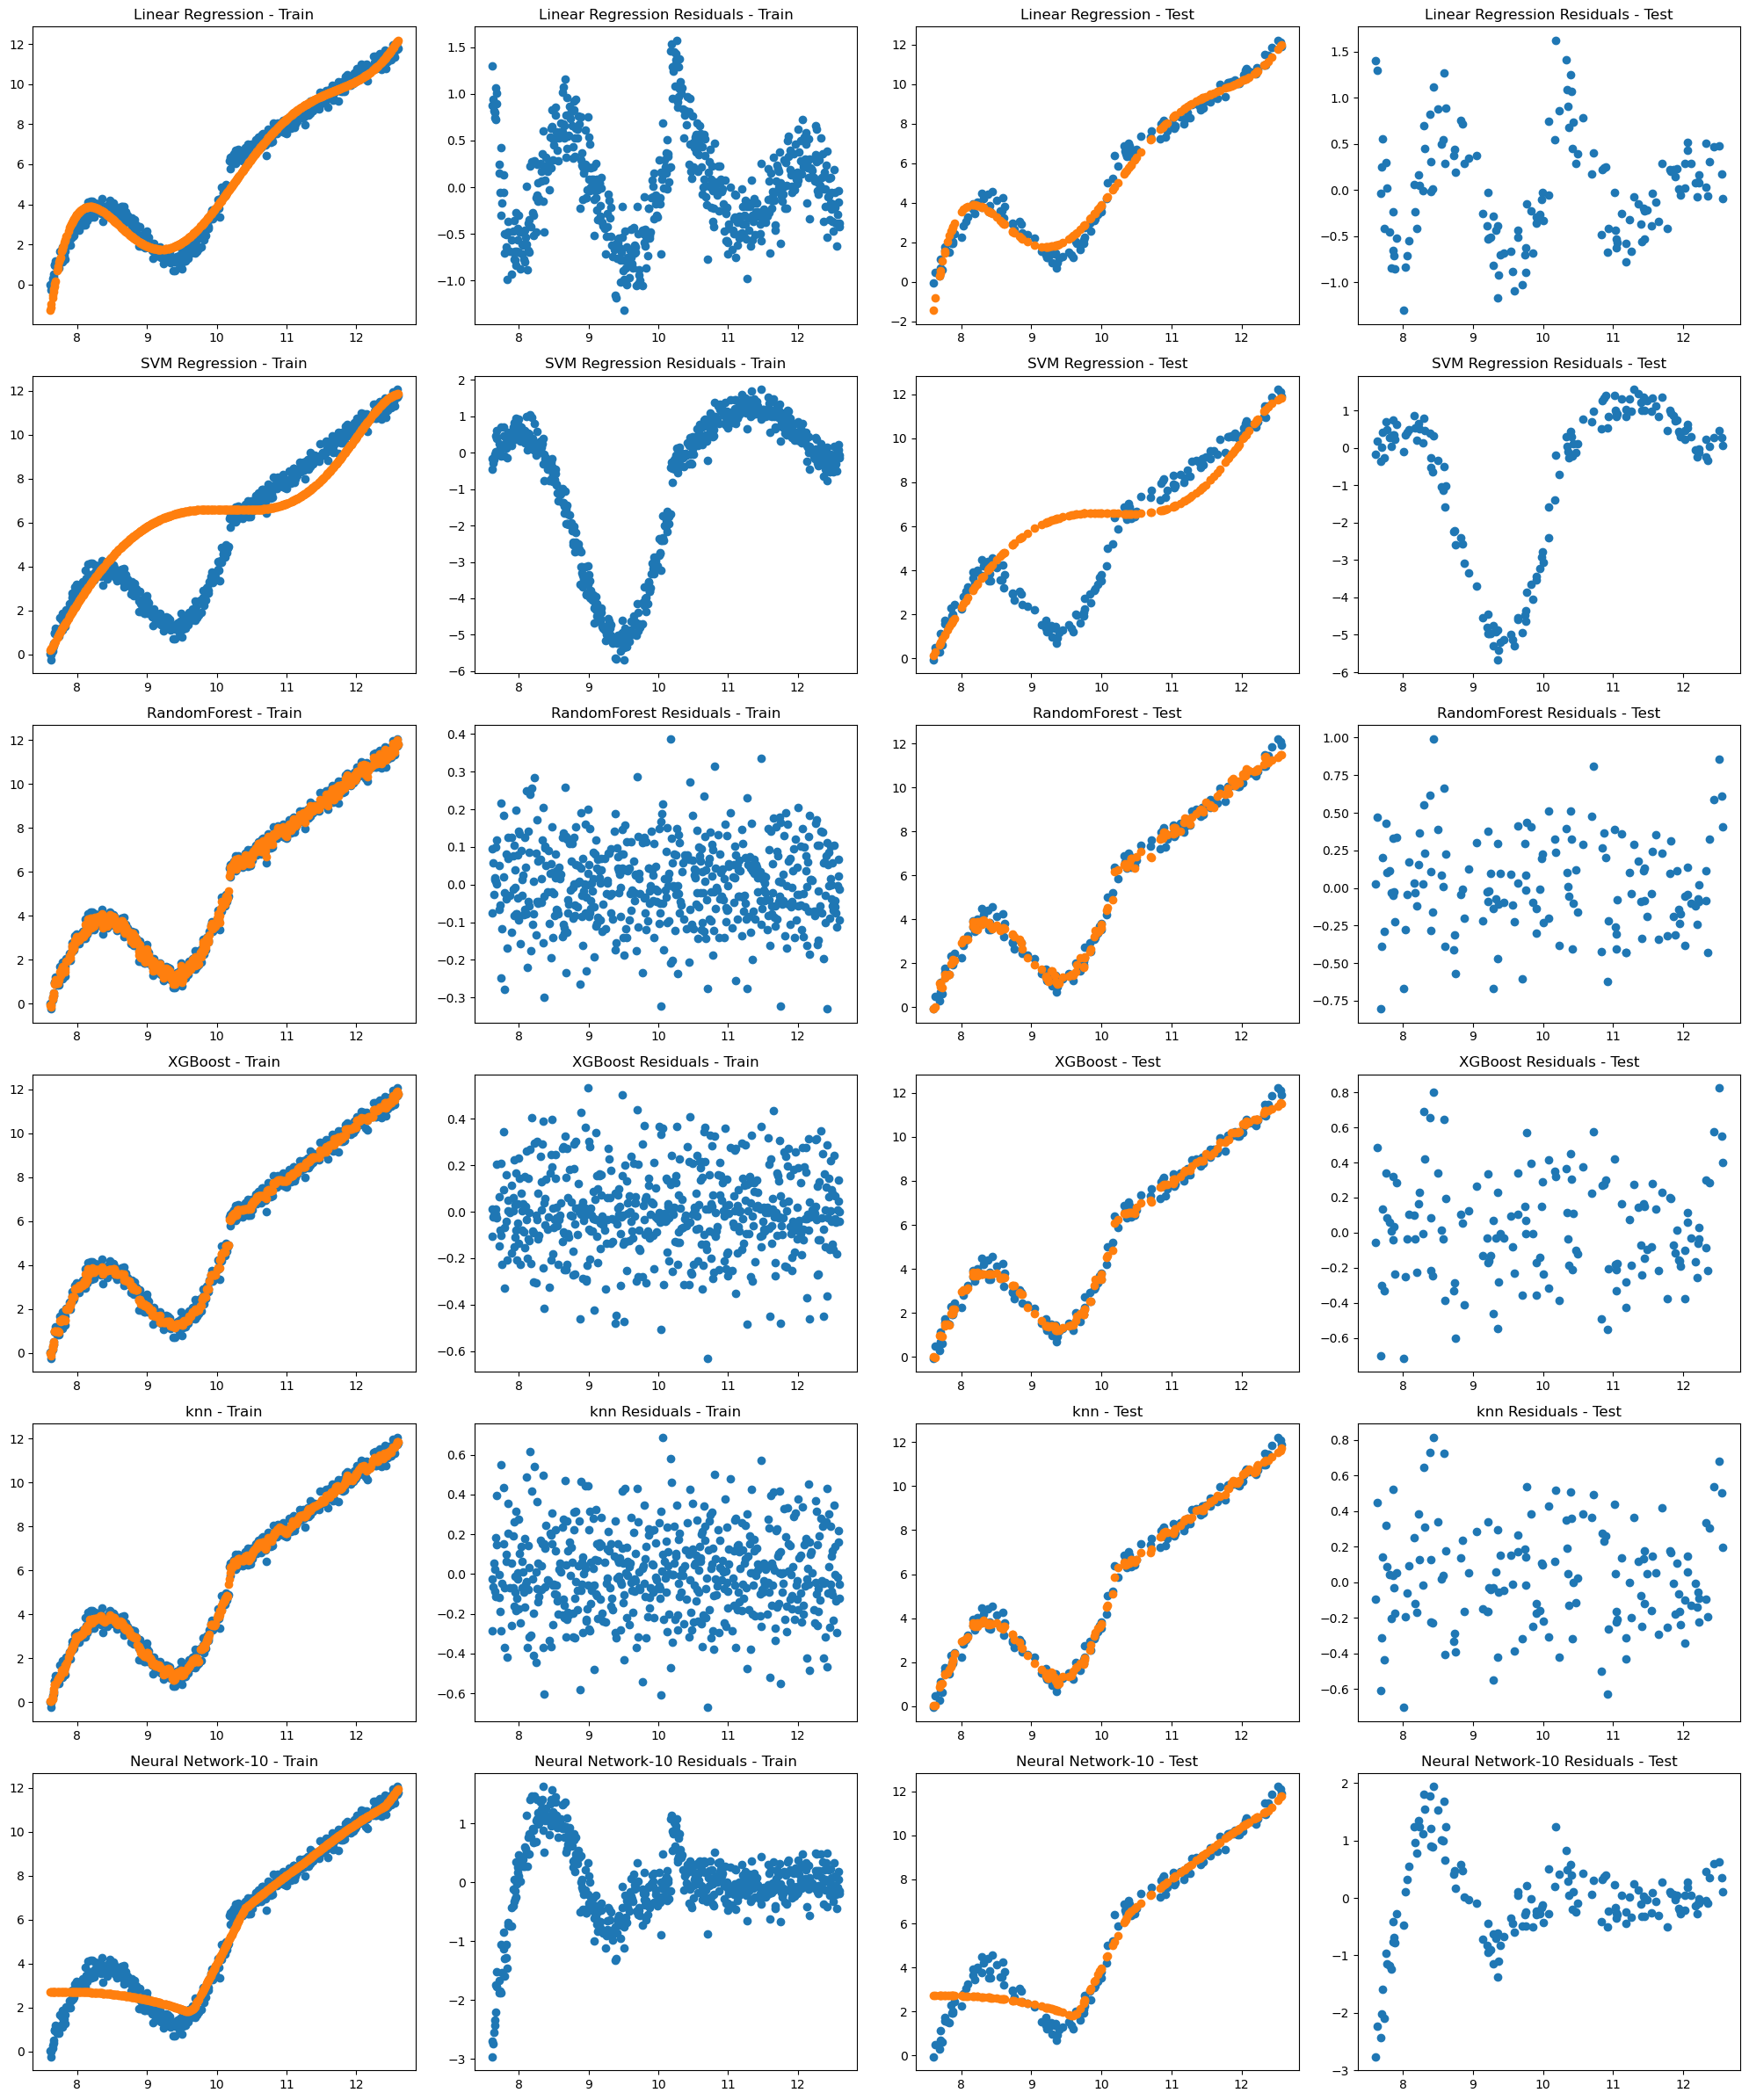

Metrics - Train Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.98  0.53           0.42        11.05        0.00
SVM Regression          0.57  2.27           0.02        83.01        0.00
RandomForest            1.00  0.11           2.93         3.04        0.22
XGBoost                 1.00  0.18           2.37         1.05        0.59
knn                     1.00  0.22           2.51         0.73        0.69
Neural Network-10       0.96  0.65           0.28       198.76        0.00
-------------------------------------------------
Metrics - Test Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.97  0.58           0.53         3.92        0.14
SVM Regression          0.58  2.29           0.04        27.18        0.00
RandomForest            0.99  0.32           1.83         0.83        0.66
XGBoost                 0.99  0.30           1.85         1.00        0.61
knn  

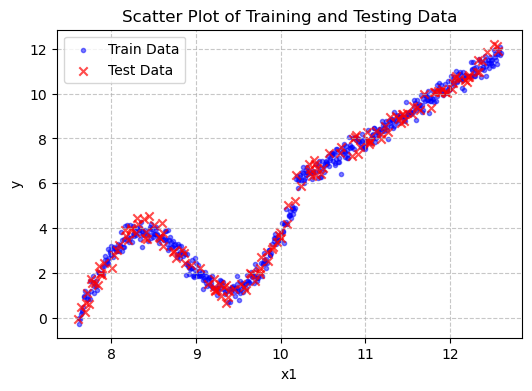

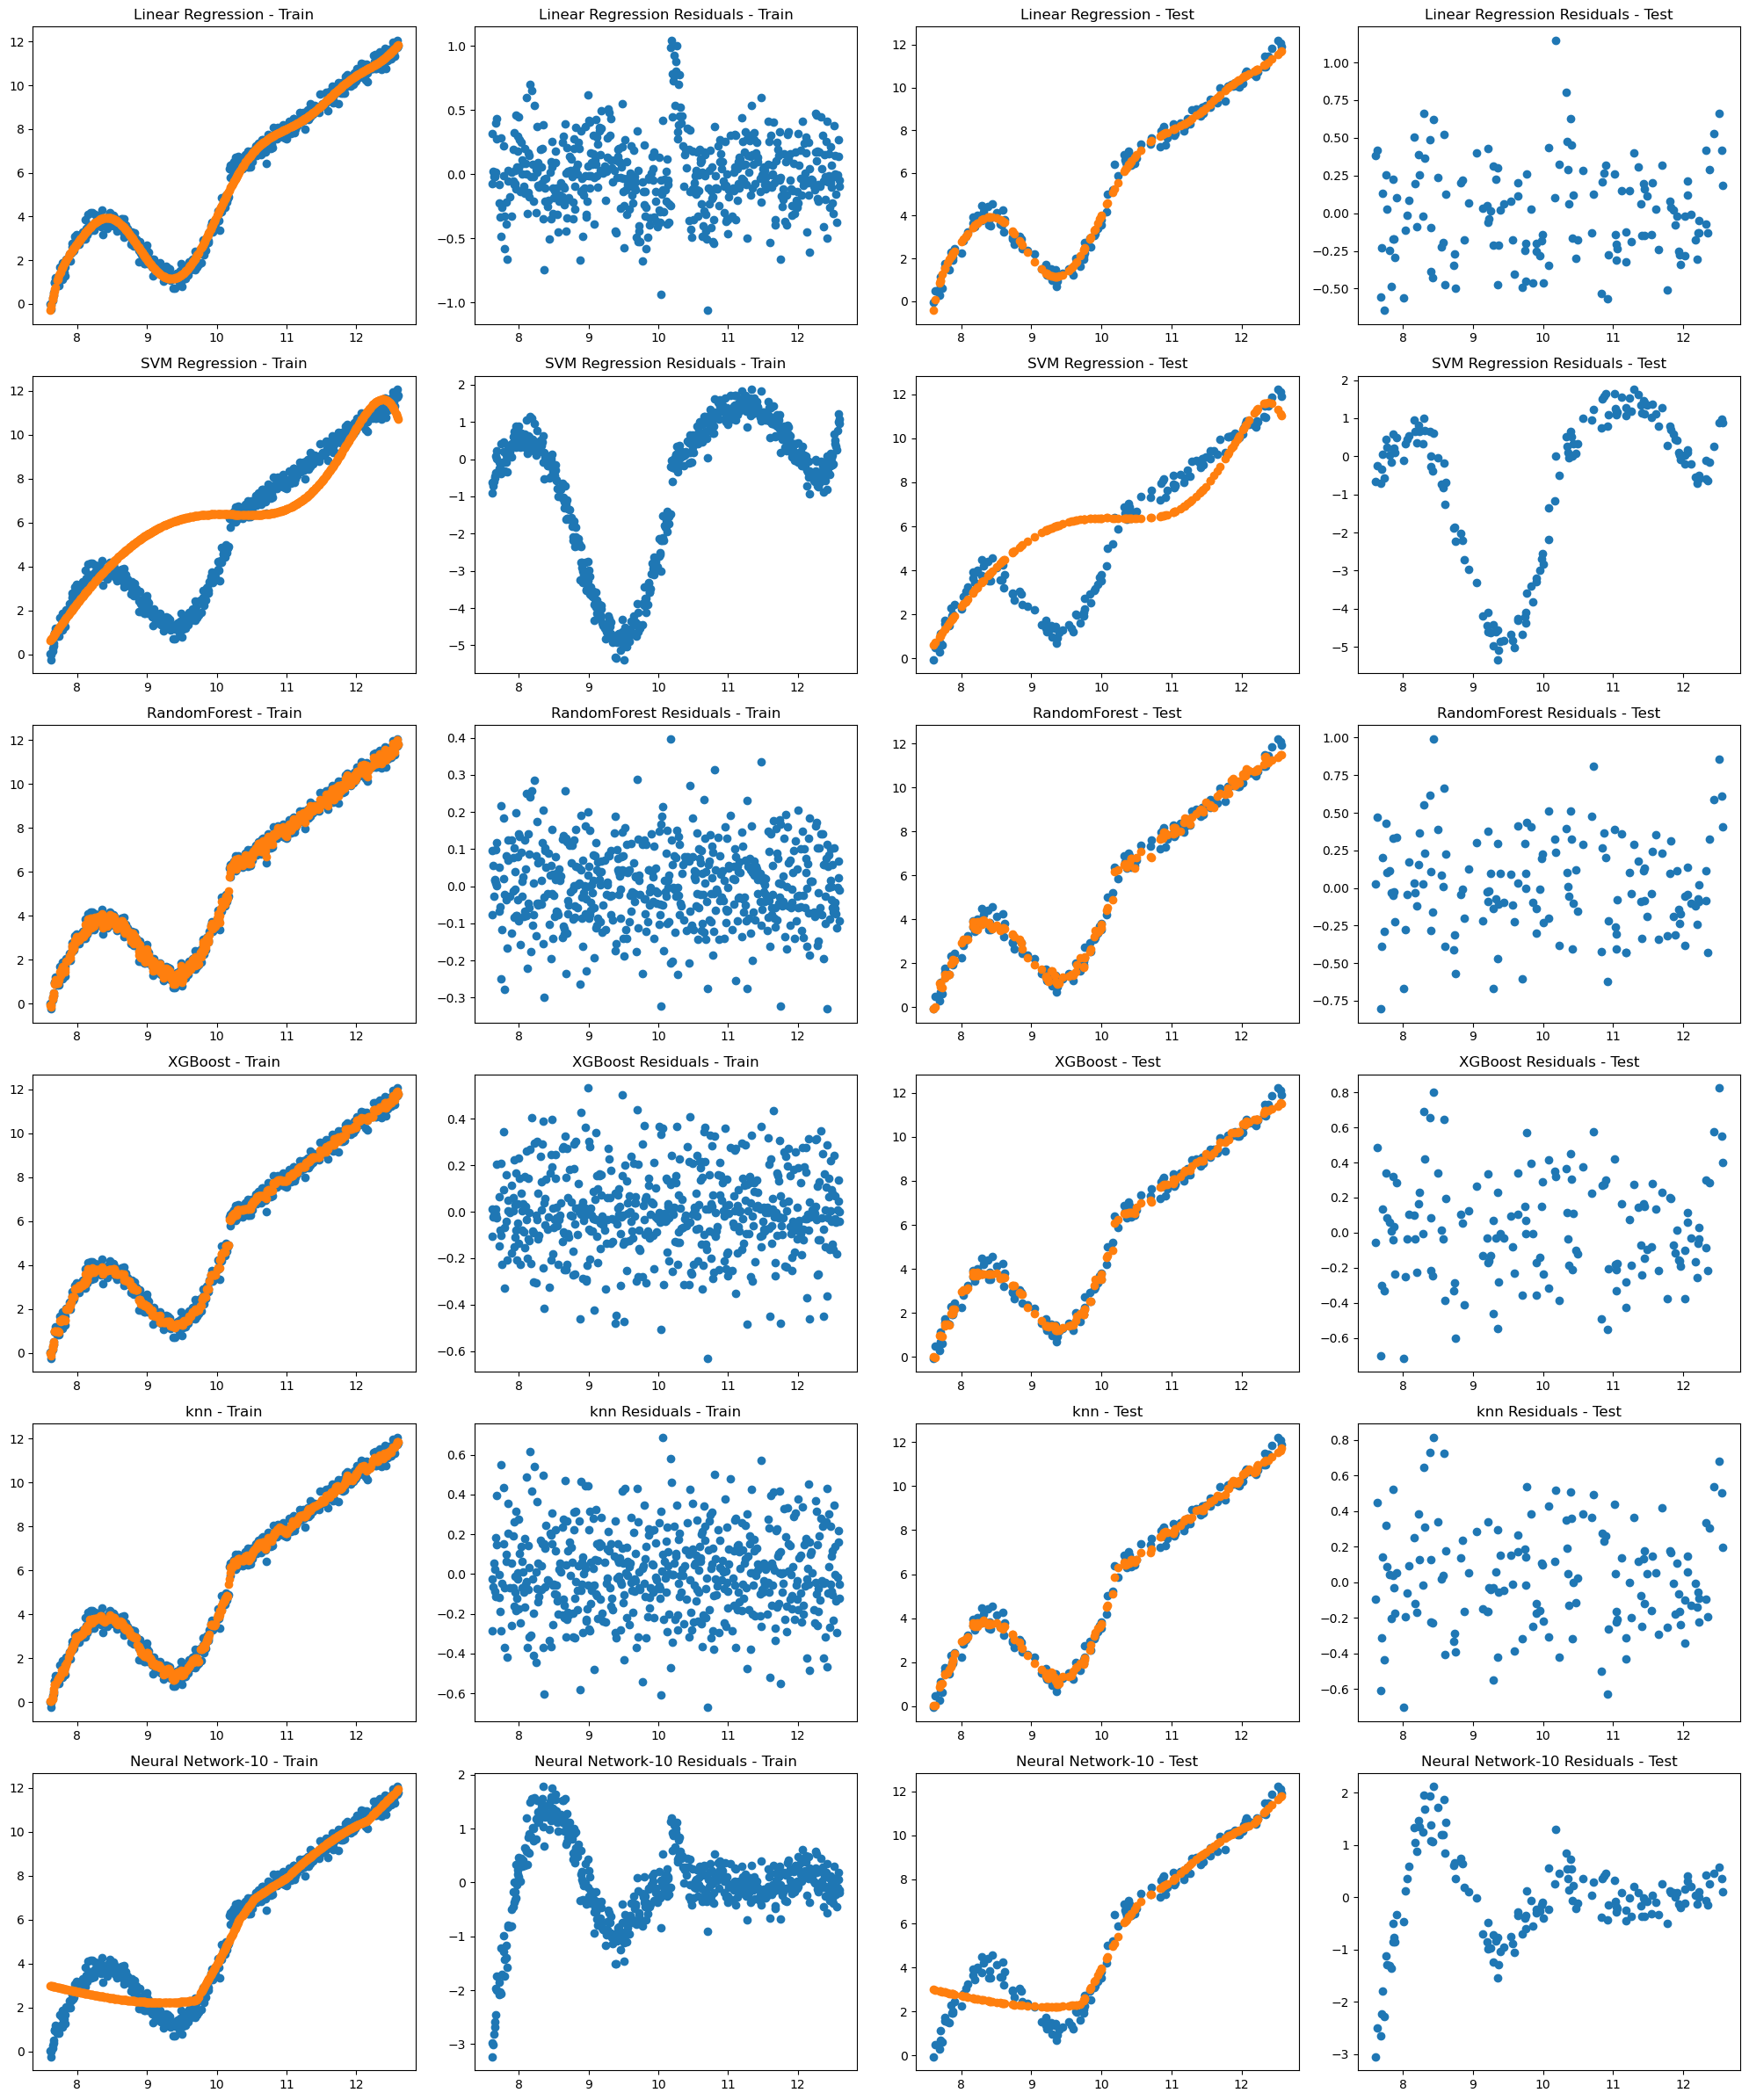

Metrics - Train Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.99  0.29           1.40        28.85        0.00
SVM Regression          0.62  2.14           0.03        76.15        0.00
RandomForest            1.00  0.11           2.93         3.38        0.18
XGBoost                 1.00  0.18           2.37         1.05        0.59
knn                     1.00  0.22           2.51         0.73        0.69
Neural Network-10       0.95  0.74           0.22       146.92        0.00
-------------------------------------------------
Metrics - Test Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.99  0.32           1.65         3.72        0.16
SVM Regression          0.62  2.16           0.04        23.88        0.00
RandomForest            0.99  0.32           1.83         0.81        0.67
XGBoost                 0.99  0.30           1.85         1.00        0.61
knn  

In [46]:
"""
2. You have been given six algorithms to study: Tree based (Random Forest and XGBoost), non￾parametric (KNN) and parametric (Linear Regression, SVR, and Neural network).
a) Run the models by setting the degree of PolynomialFeatures() to 1, 6 and 10.
b) Analyze the plots, metrics and state your conclusions.
c) Have any of these models overfitted the training data? Justify your conclusions.
d) Based on the plots, comment on which ML algorithms seem to be affected the most by the polynomial degree, based on visual inspection? Why?
i) Are the train RMSE values in agreement with your observations and conclusions?
"""

for dof in (1, 6, 10):
    print(f"-----------------Running with polynomial degree={dof}---------------------")
    run_ml_models(dof)

-----Without Standardization-----


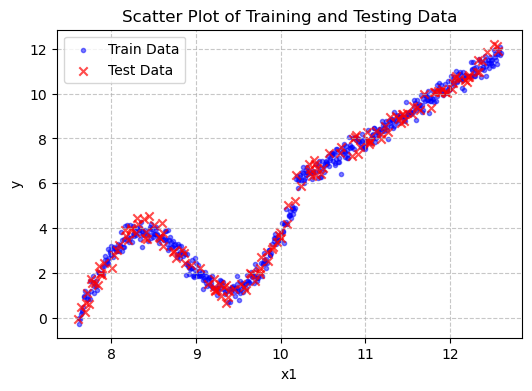

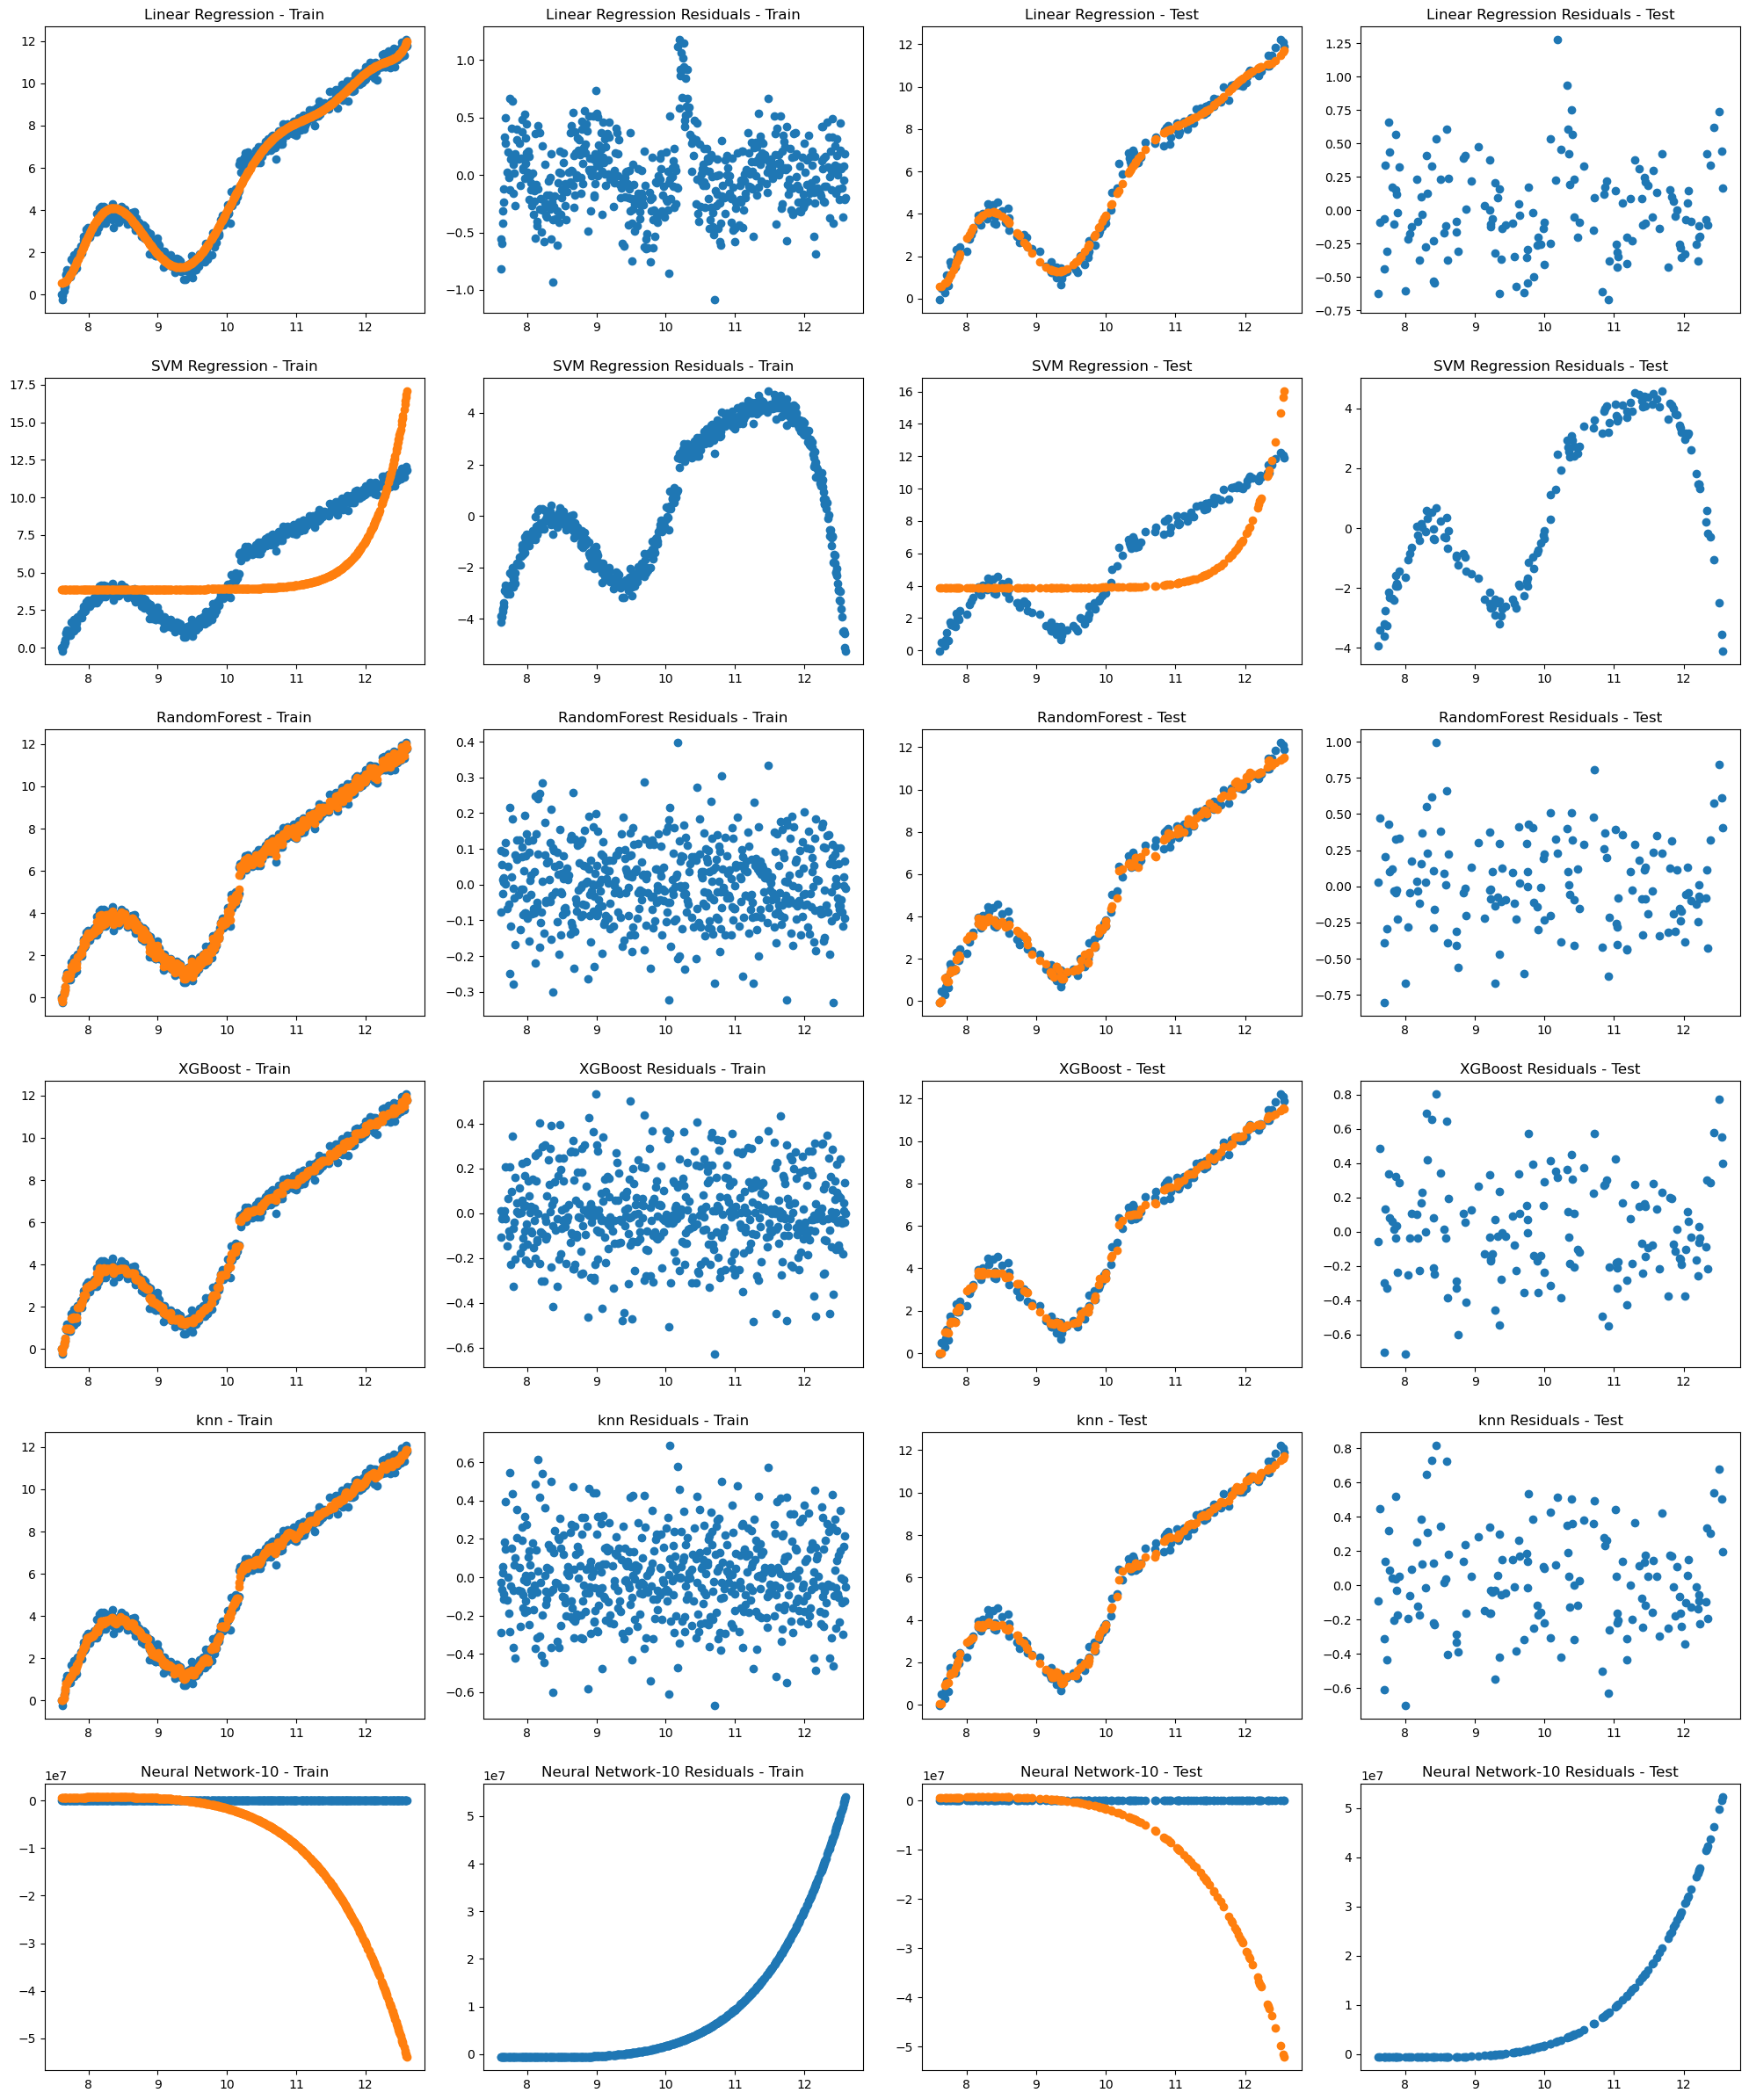

----RMSE Train---- 
Linear Regression          0.32
SVM Regression             2.69
RandomForest               0.11
XGBoost                    0.18
knn                        0.22
Neural Network-10   17124852.22
Name: RMSE, dtype: float64
----RMSE Test----
Linear Regression          0.34
SVM Regression             2.67
RandomForest               0.32
XGBoost                    0.30
knn                        0.29
Neural Network-10   16468924.82
Name: RMSE, dtype: float64
-----With Standardization-----


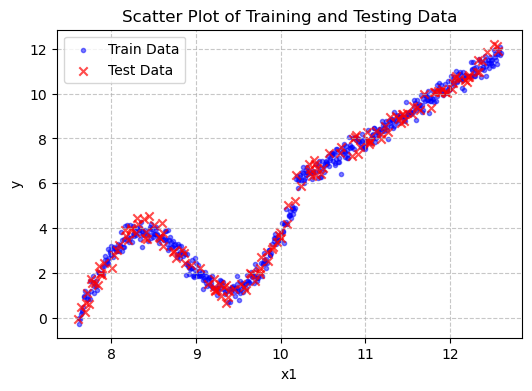

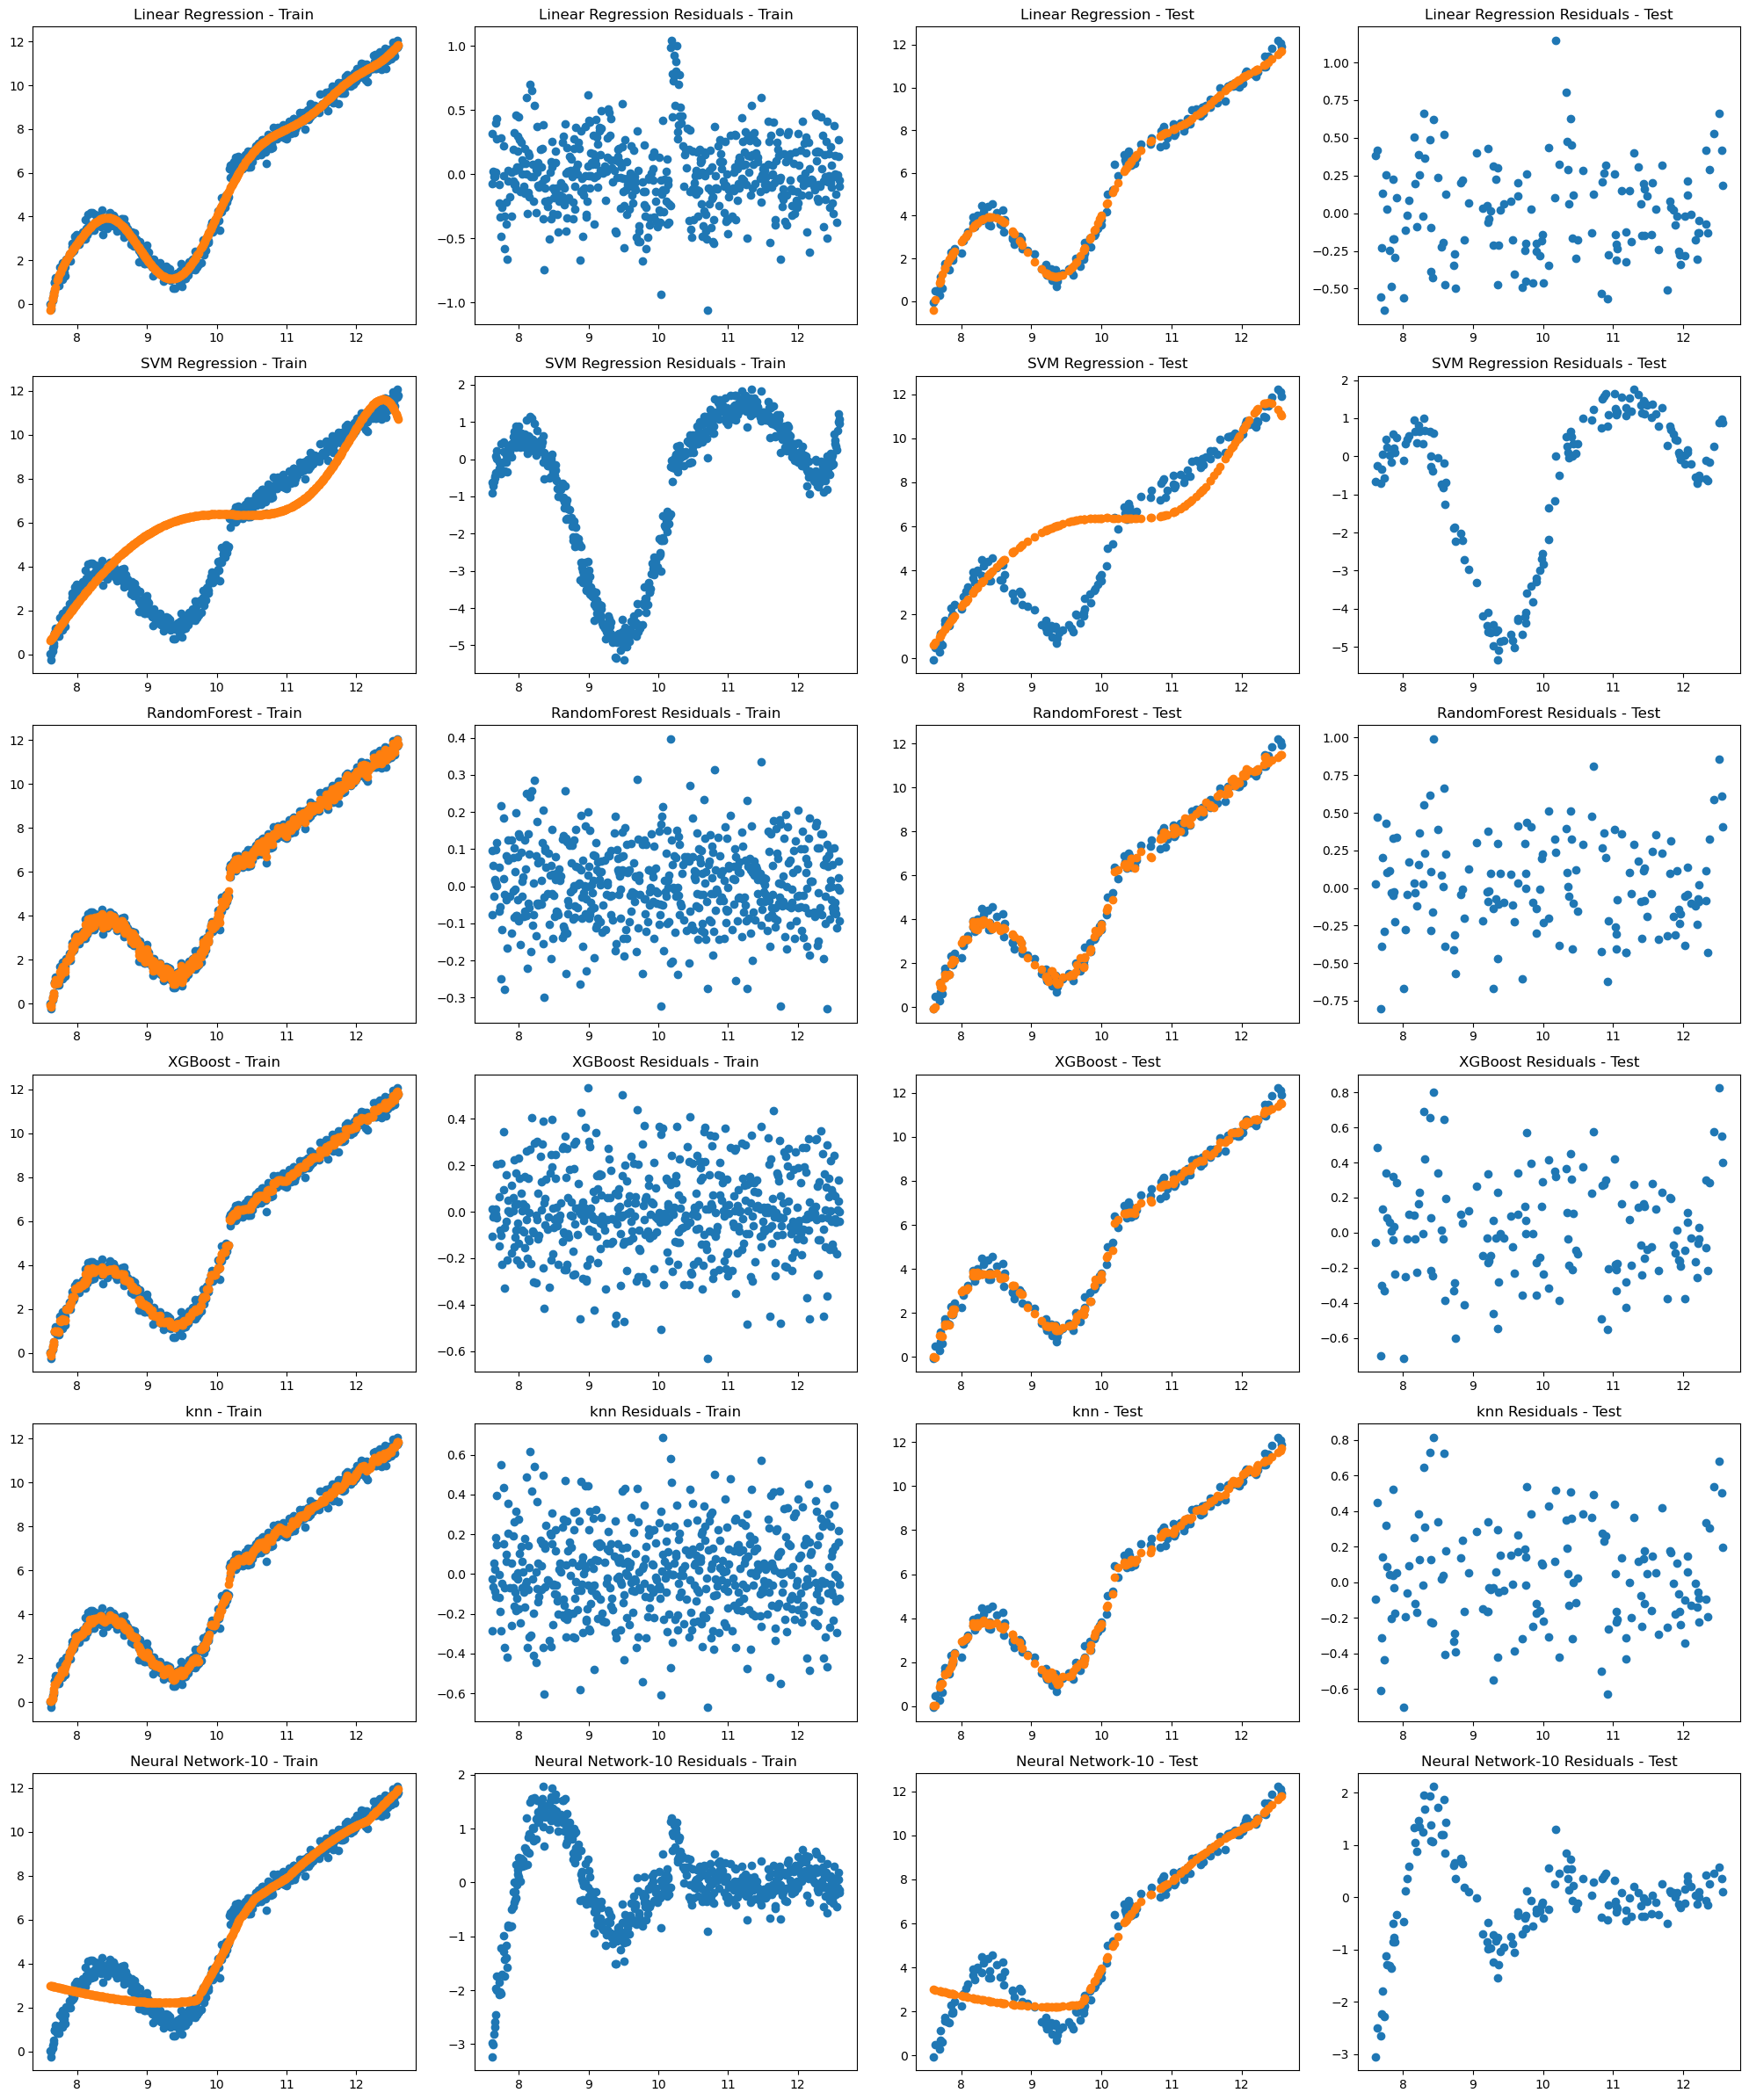

----RMSE Train---- 
Linear Regression   0.29
SVM Regression      2.14
RandomForest        0.11
XGBoost             0.18
knn                 0.22
Neural Network-10   0.74
Name: RMSE, dtype: float64
----RMSE Test----
Linear Regression   0.32
SVM Regression      2.16
RandomForest        0.32
XGBoost             0.30
knn                 0.29
Neural Network-10   0.87
Name: RMSE, dtype: float64


In [47]:
"""
Set the polynomial degree to 10 and tabulate the RMSEs (both train and test) of the six models, with and without standardization.
a) Which models are affected the most, and which are not?
b) Why?
"""
print(f"-----Without Standardization-----")
pd.set_option('display.float_format', '{:.2f}'.format)
metrics_train, metrics_test = run_ml_models(10, draw_plots=False, enable_standardization=False, print_metrics=False)
print("----RMSE Train---- ")
print(metrics_train['RMSE'])
print("----RMSE Test----")
print(metrics_test['RMSE'])

print(f"-----With Standardization-----")
metrics_train, metrics_test = run_ml_models(10, draw_plots=False, enable_standardization=True, print_metrics=False)
print("----RMSE Train---- ")
print(metrics_train['RMSE'])
print("----RMSE Test----")
print(metrics_test['RMSE'])



In [48]:
"""
7. What are the advantages and limitations of the non-parametric methods?
Advantages: flexible, assumption-free, capable of modeling complex real patterns.
Limitations: need lots of data, slow, less interpretable, and prone to overfitting.
"""

'\n7. What are the advantages and limitations of the non-parametric methods?\nAdvantages: flexible, assumption-free, capable of modeling complex real patterns.\nLimitations: need lots of data, slow, less interpretable, and prone to overfitting.\n'

-----With Outliers------


C:\Users\swapn\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


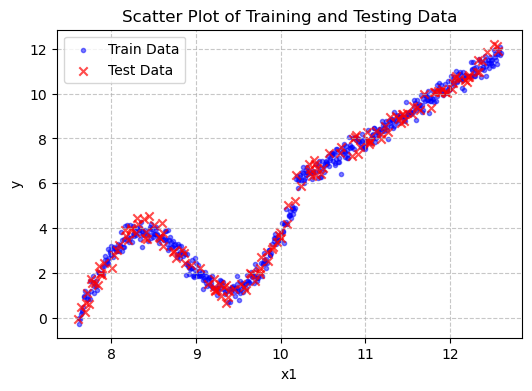

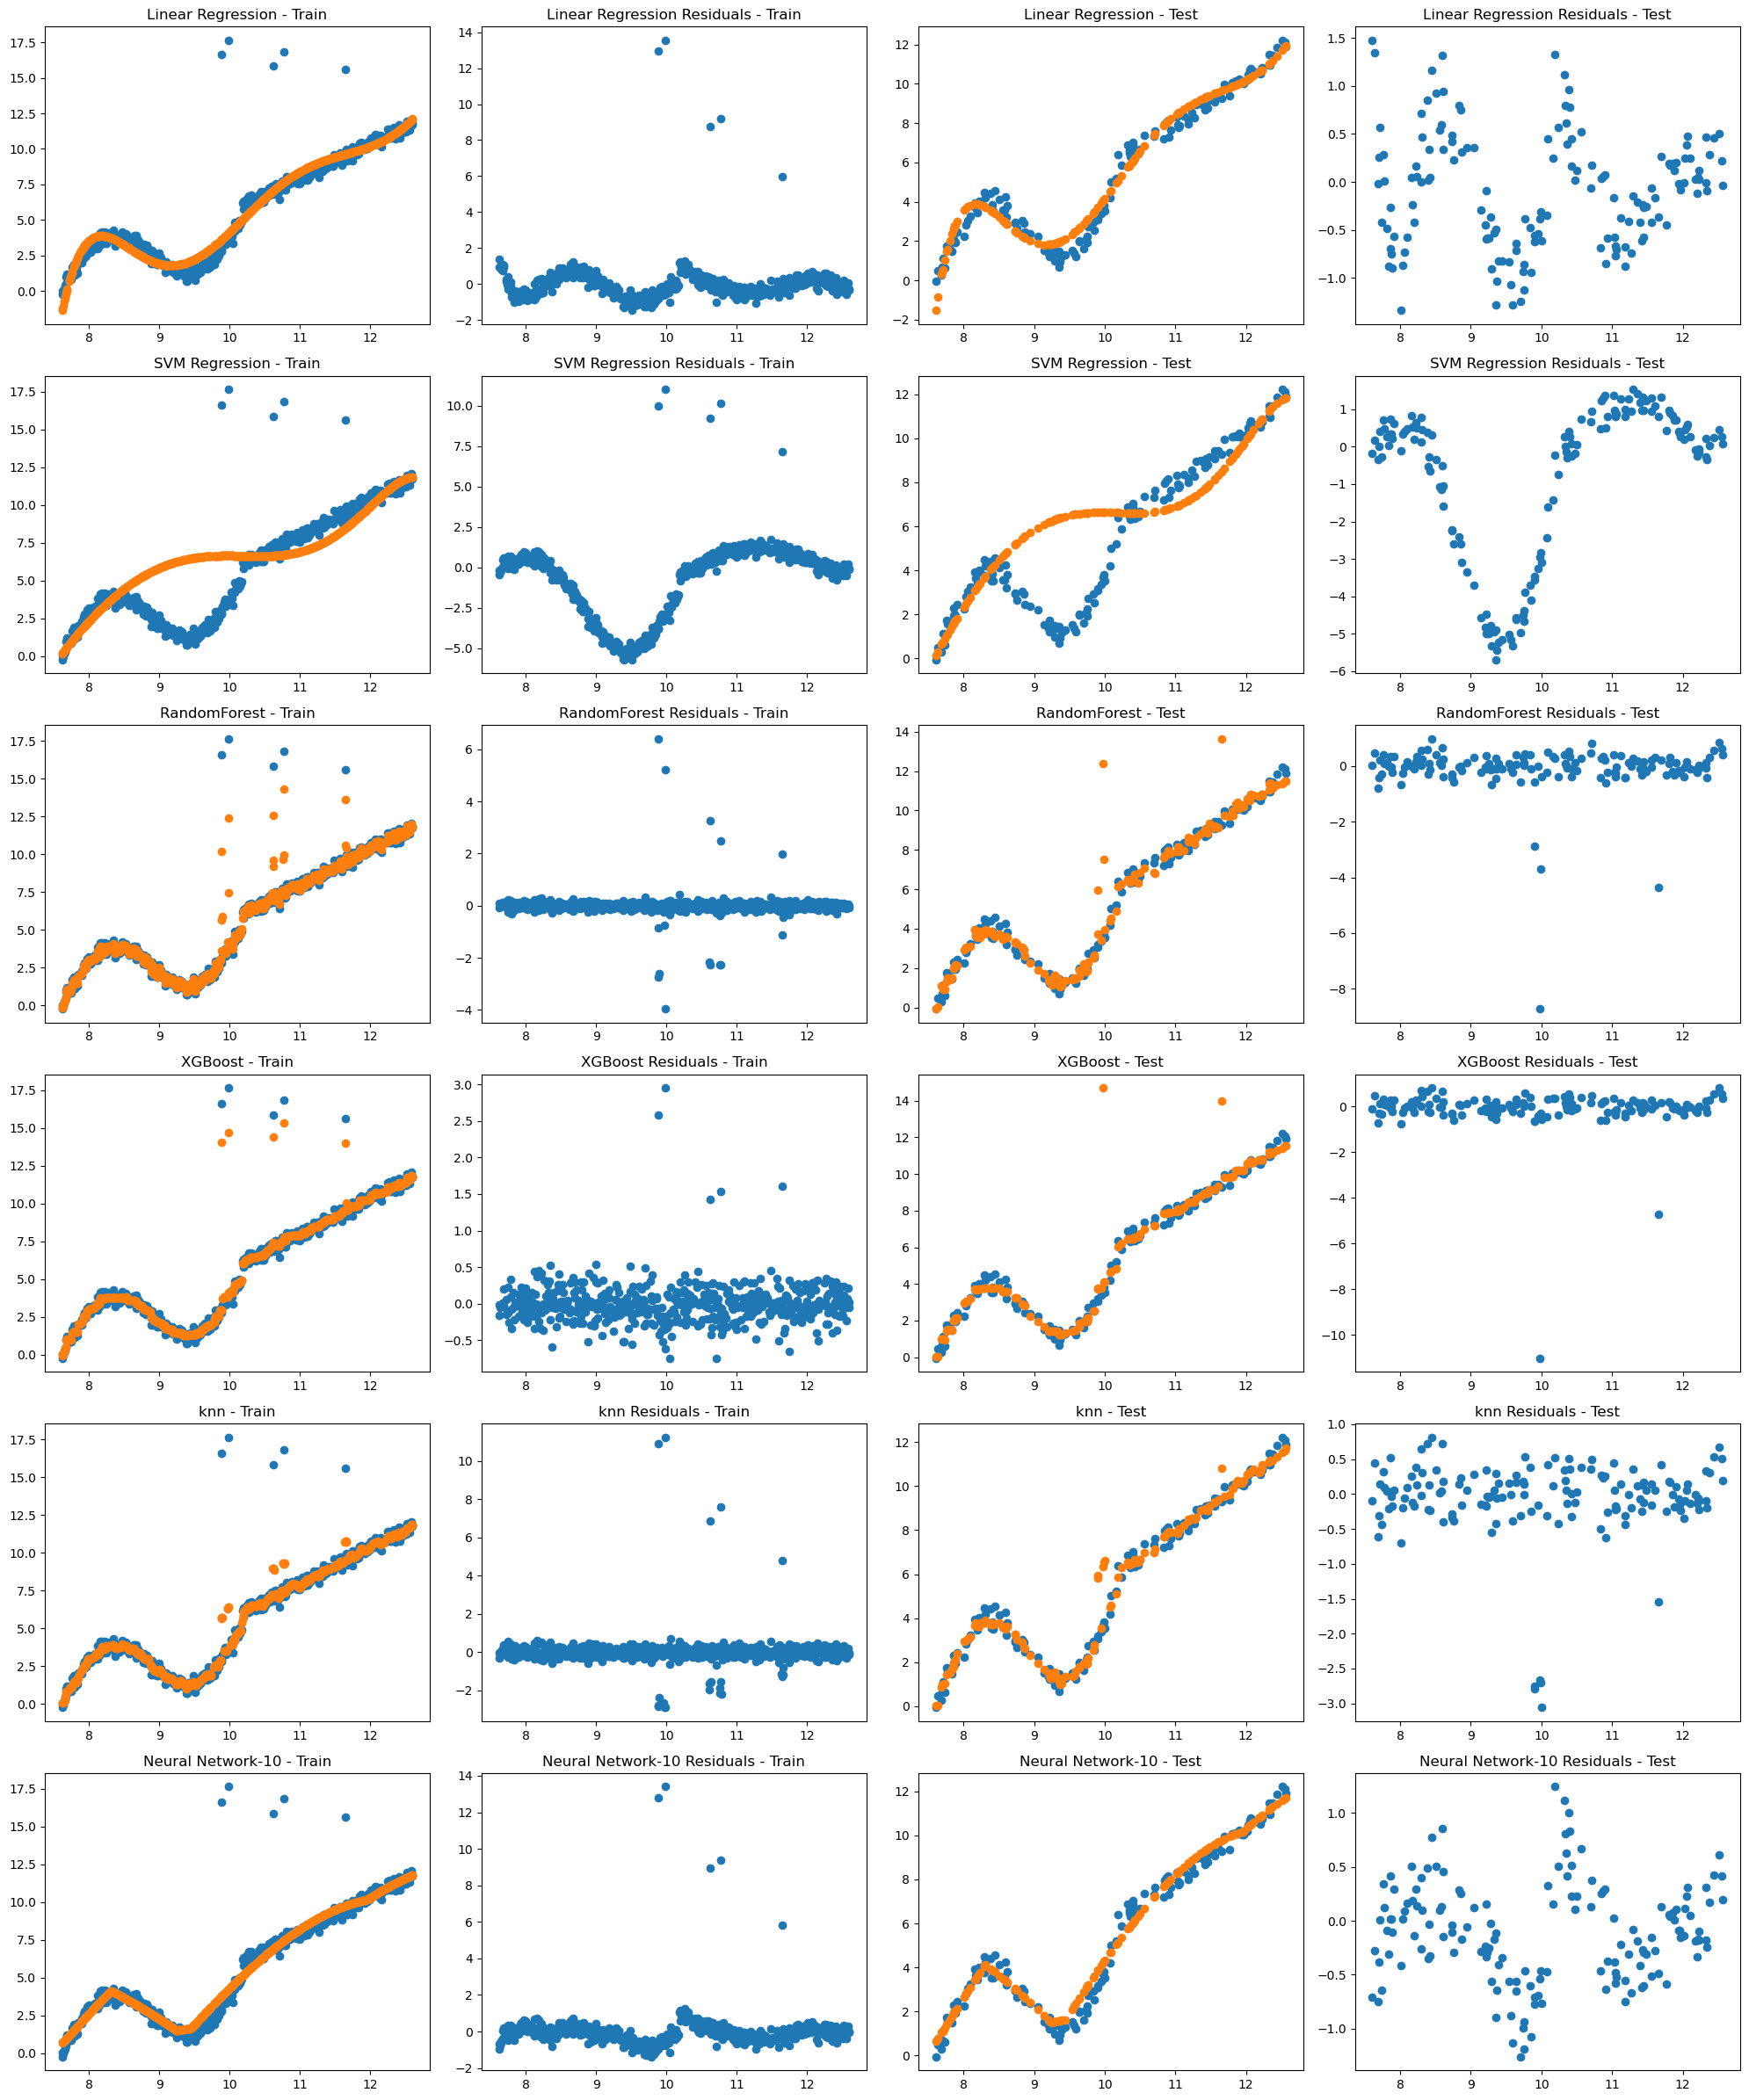

Metrics - Train Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.90  1.14           0.35    151552.43        0.00
SVM Regression          0.53  2.45           0.05       151.69        0.00
RandomForest            0.98  0.52           0.77    125542.54        0.00
XGBoost                 0.99  0.29           1.25     29119.90        0.00
knn                     0.93  0.93           0.50    175594.59        0.00
Neural Network-10       0.91  1.09           0.37    210810.17        0.00
-------------------------------------------------
Metrics - Test Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.97  0.60           0.49         2.52        0.28
SVM Regression          0.57  2.30           0.04        27.32        0.00
RandomForest            0.93  0.93           1.47     17518.68        0.00
XGBoost                 0.92  1.02           1.89     50480.73        0.00
knn  

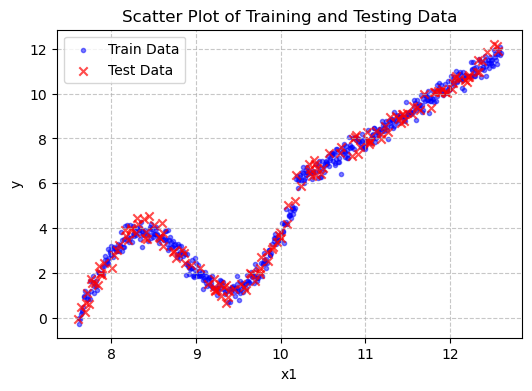

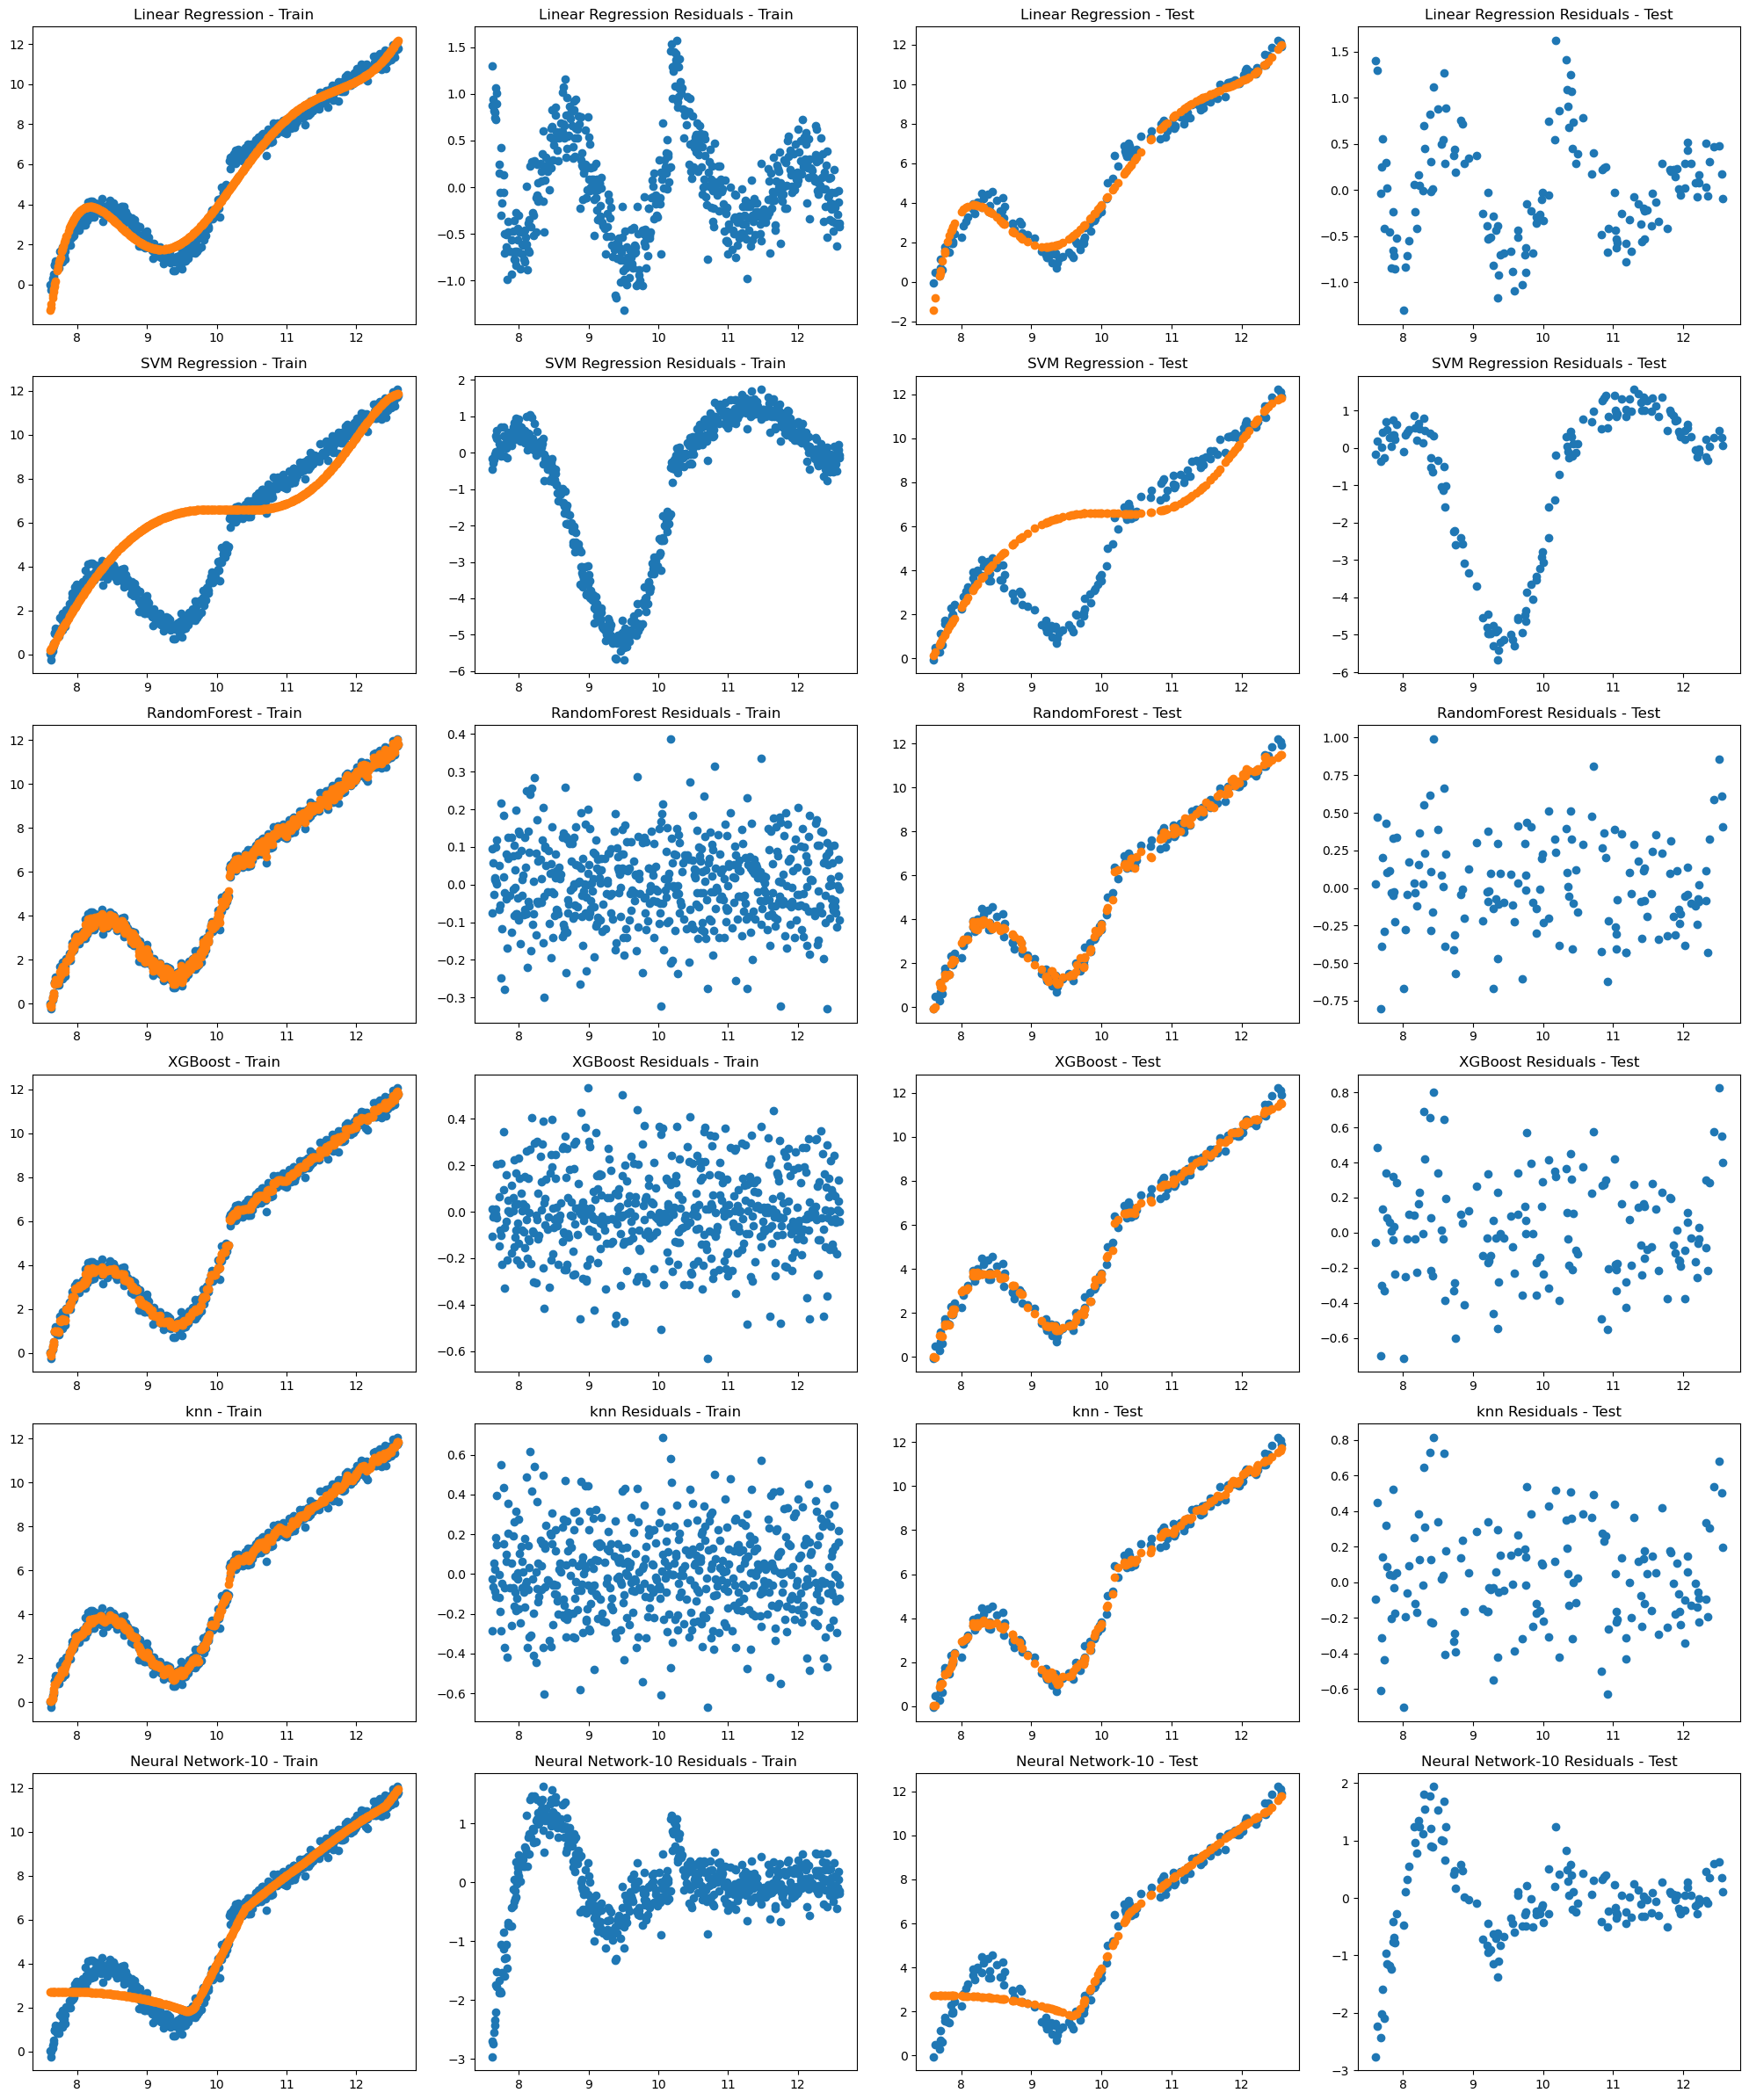

Metrics - Train Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.98  0.53           0.42        11.05        0.00
SVM Regression          0.57  2.27           0.02        83.01        0.00
RandomForest            1.00  0.11           2.93         3.04        0.22
XGBoost                 1.00  0.18           2.37         1.05        0.59
knn                     1.00  0.22           2.51         0.73        0.69
Neural Network-10       0.96  0.65           0.28       198.76        0.00
-------------------------------------------------
Metrics - Test Data:

                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression       0.97  0.58           0.53         3.92        0.14
SVM Regression          0.58  2.29           0.04        27.18        0.00
RandomForest            0.99  0.32           1.83         0.83        0.66
XGBoost                 0.99  0.30           1.85         1.00        0.61
knn  

(                   R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
 Linear Regression       0.98  0.53           0.42        11.05        0.00
 SVM Regression          0.57  2.27           0.02        83.01        0.00
 RandomForest            1.00  0.11           2.93         3.04        0.22
 XGBoost                 1.00  0.18           2.37         1.05        0.59
 knn                     1.00  0.22           2.51         0.73        0.69
 Neural Network-10       0.96  0.65           0.28       198.76        0.00,
                    R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
 Linear Regression       0.97  0.58           0.53         3.92        0.14
 SVM Regression          0.58  2.29           0.04        27.18        0.00
 RandomForest            0.99  0.32           1.83         0.83        0.66
 XGBoost                 0.99  0.30           1.85         1.00        0.61
 knn                     0.99  0.29           1.99         1.27        0.53
 Neural Net

In [52]:
"""
5. Set the degree to 6 and repeat the following before and after adding the outliers (uncomment the outlier related code):
a) Which models seem unaffected by outliers? Can you explain why?
b) What does this tell you about the choice of models in situations where noisy data is expected
"""
print("-----With Outliers------")
run_ml_models(polynomial_dof=6, enable_outliers=True)
print("-----Without outliers------")
run_ml_models(polynomial_dof=6, enable_outliers=False)

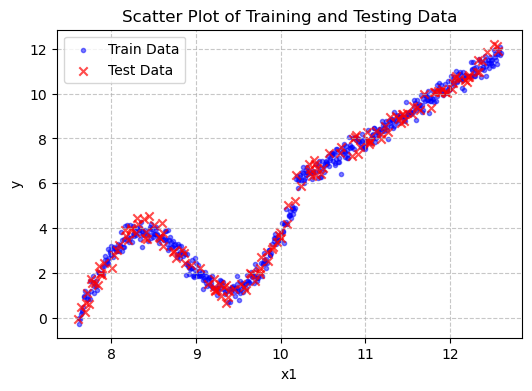

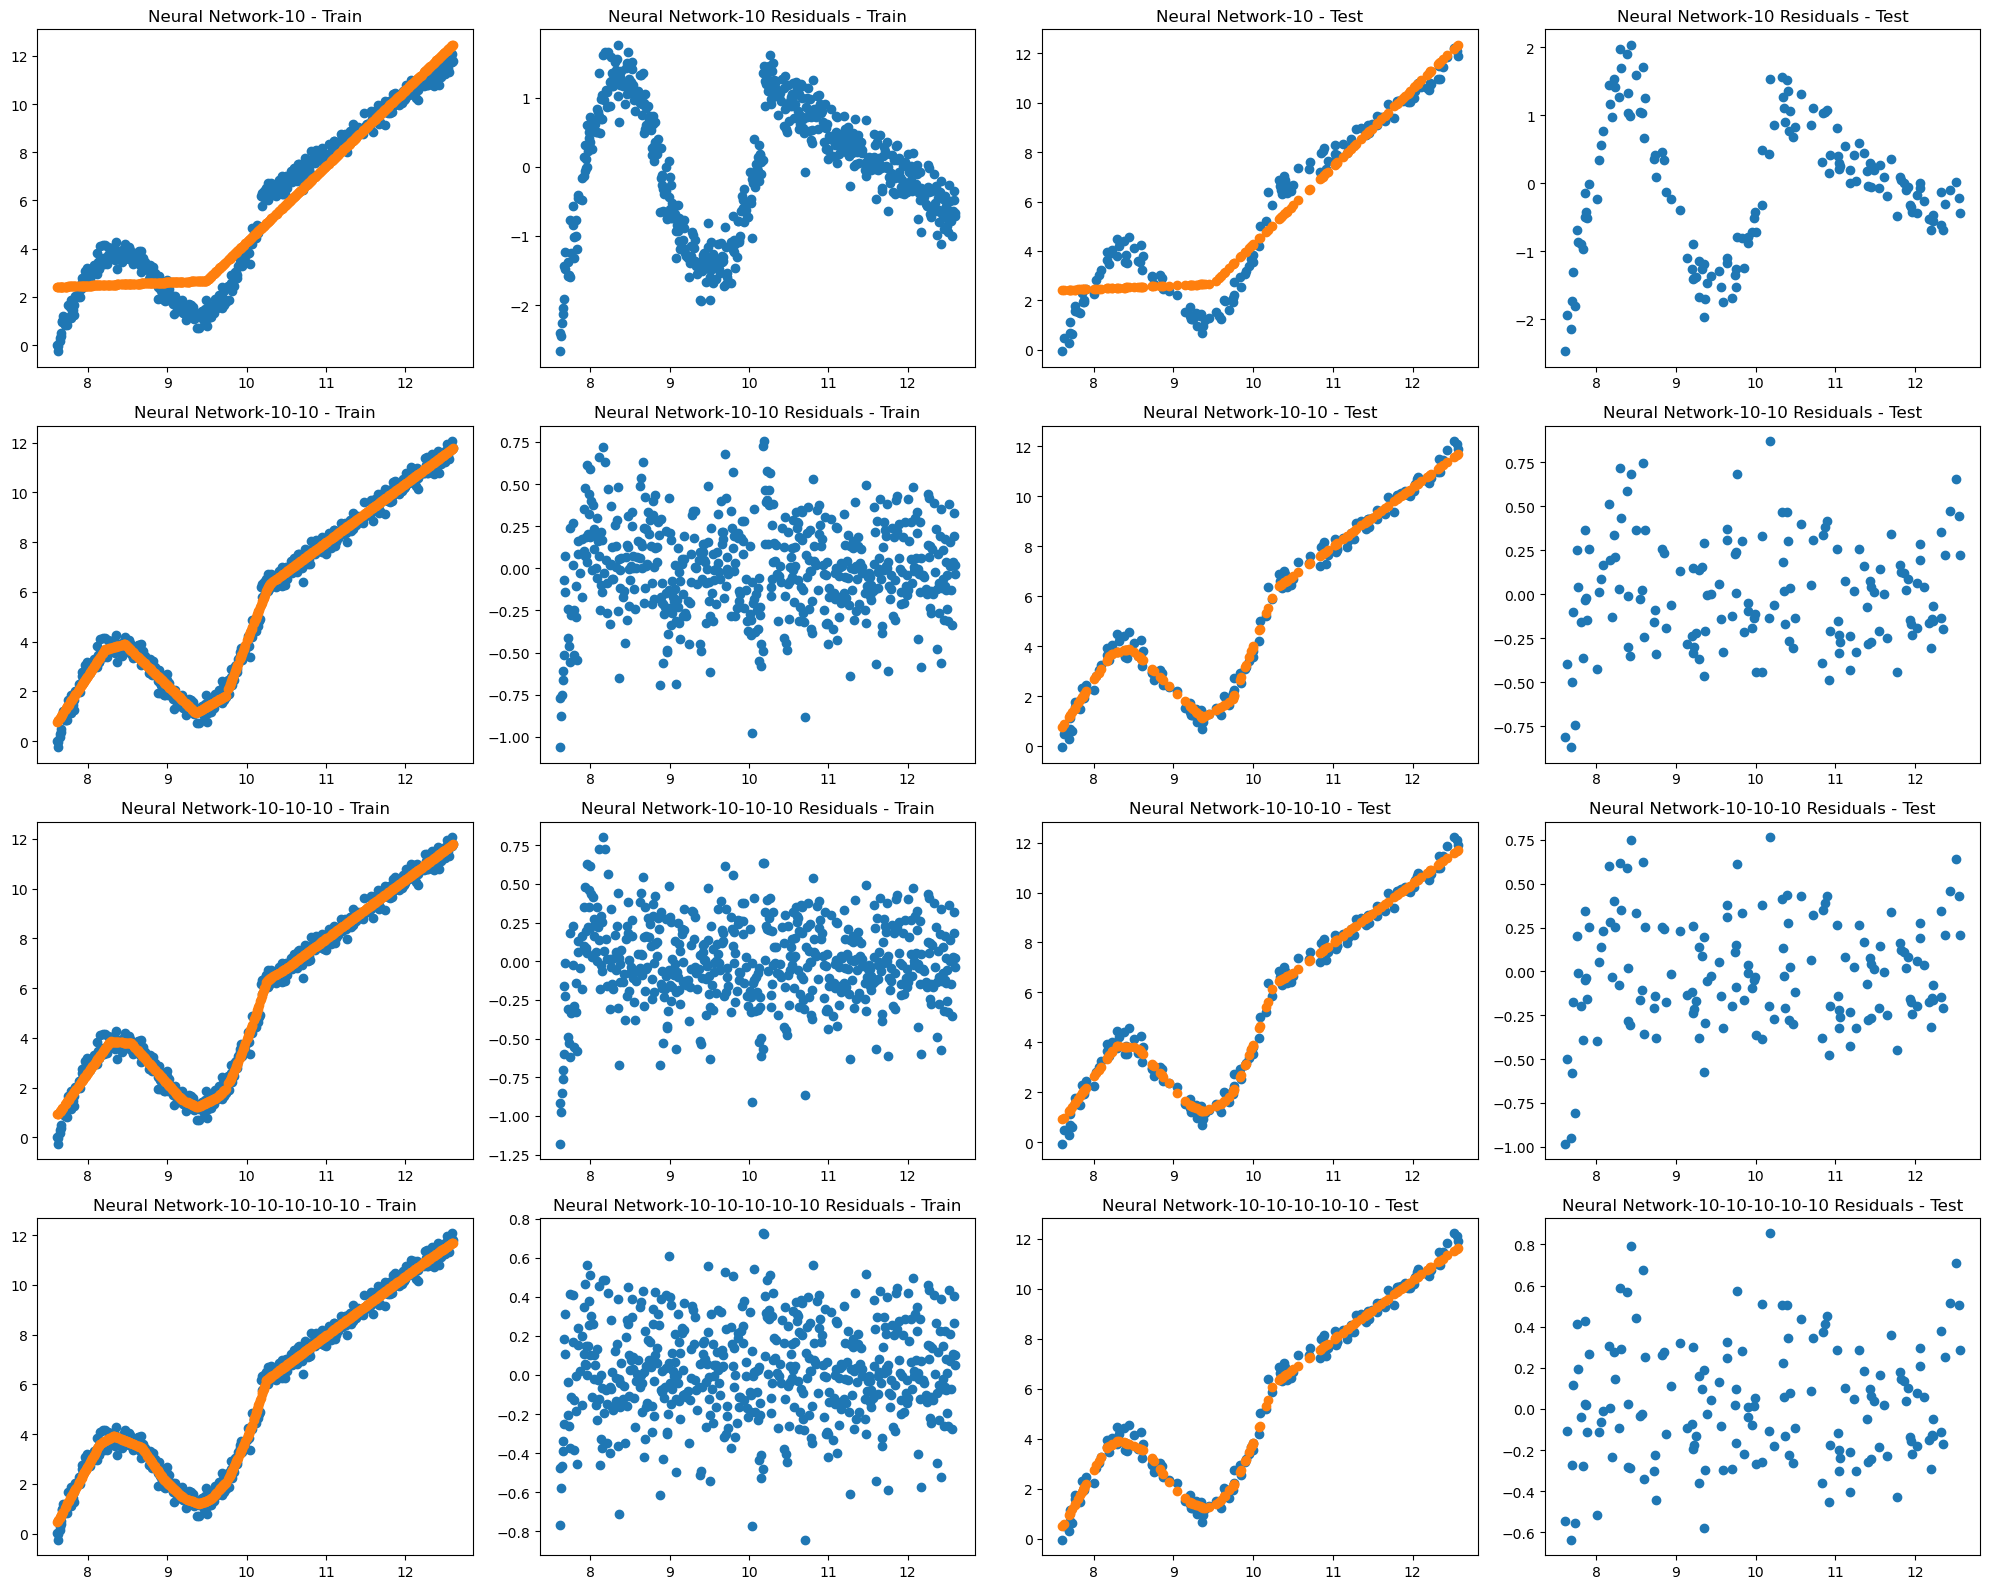

Metrics - Train Data:

                               R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Neural Network-10                   0.93  0.90           0.15        17.22        0.00
Neural Network-10-10                0.99  0.28           1.50        12.67        0.00
Neural Network-10-10-10             0.99  0.28           1.51        34.84        0.00
Neural Network-10-10-10-10-10       0.99  0.26           1.80         2.91        0.23
-------------------------------------------------
Metrics - Test Data:

                               R-squared  RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Neural Network-10                   0.92  0.99           0.18         2.75        0.25
Neural Network-10-10                0.99  0.31           1.68         0.63        0.73
Neural Network-10-10-10             0.99  0.31           1.70         0.76        0.69
Neural Network-10-10-10-10-10       0.99  0.29           1.94         3.07        0.22


In [60]:
"""
6. Set the polynomial degree to 1, apply standardization, and run the Neural Network with 1, 2 and 3 hidden layers (each layer having 10 neurons).
    a) Analyze the plots, metrics and state your conclusions.
"""
run_ml_models(polynomial_dof=1, draw_plots=True, enable_standardization=True, analyze_neural_net_algos=True);

***9. List your major learnings from this exercise***


1. Understanding multiple regression algorithms
2. Effect of polynomial degree
3. Importance of standardization
4. Understanding overfitting and generalization
5. Impact of outliers
6. Understanding of various performance metrics in order to evaluate the model appropriately